# <center>Práctica 09: Algoritmos de Análisis No Supervisado</center>
# <center>Segmentación de Clientes de Centros Comerciales</center>

---

| | |
|---|---|
| **Institución** | Tecnológico Nacional de México — Instituto Tecnológico de Aguascalientes |
| **Asignatura** | Estadística Computacional y Big Data |
| **Unidad** | Unidad 4 — Aprendizaje No Supervisado |
| **Práctica** | Práctica 09: Algoritmos de Análisis No Supervisado — Clientes de Centros Comerciales |
| **Estudiante** | Francisco Garcia Garcia |
| **Matrícula** | 230758 |
| **Grupo** | 9°A — Ingeniería en Desarrollo y Gestión de Software |
| **Fecha** | Agosto 2026 |
| **Notebook Original** | [Unsupervised Learning: 3-6 Clusters \| K-Means \| EDA — Kaggle](https://www.kaggle.com/code/tanmay111999/unsupervised-learning-3-6-clusters-k-means-eda) |

---


## 1. Introducción

### ¿Qué es el Aprendizaje No Supervisado (Unsupervised Learning)?

El **aprendizaje no supervisado** es una rama del aprendizaje automático (Machine Learning) en la cual los algoritmos trabajan con datos que **no poseen una variable objetivo o etiqueta predefinida**. A diferencia del aprendizaje supervisado — donde el modelo aprende a partir de ejemplos etiquetados (por ejemplo, "spam" o "no spam") —, en el aprendizaje no supervisado el algoritmo debe **descubrir patrones, estructuras o agrupaciones ocultas** dentro de los datos por sí mismo.

Este enfoque es especialmente útil cuando:
- No se conoce de antemano cuántos grupos existen en los datos.
- Se busca explorar la estructura interna de un conjunto de datos.
- Se requiere reducir la dimensionalidad o detectar anomalías.

### ¿Qué problema resuelve el Agrupamiento (Clustering)?

El **agrupamiento** o **clustering** es una técnica de aprendizaje no supervisado que consiste en dividir un conjunto de datos en **grupos (clústeres)** de tal forma que los elementos dentro de un mismo grupo sean lo más **similares** entre sí y lo más **diferentes** posible respecto a los elementos de otros grupos.

En el contexto empresarial, el agrupamiento permite:
- **Segmentar clientes** según su comportamiento de compra.
- **Identificar perfiles** de usuarios para personalizar estrategias de marketing.
- **Detectar patrones** que no son evidentes a simple vista en datos tabulares.

### ¿Por qué aplicar K-Means en la segmentación de clientes?

**K-Means** es uno de los algoritmos de agrupamiento más utilizados debido a su simplicidad, eficiencia computacional y facilidad de interpretación. En esta práctica, lo aplicamos al dataset `Mall_Customers.csv` — un conjunto de 200 registros de clientes de un centro comercial — con el objetivo de:

1. **Identificar segmentos de clientes** con base en su edad, ingreso anual y puntuación de gasto.
2. **Evaluar el número óptimo de clústeres** mediante el método del codo (Elbow Method) y el coeficiente de silueta (Silhouette Score).
3. **Comparar los resultados** obtenidos con datos originales y datos normalizados.
4. **Construir diagramas tridimensionales (3D)** tanto estáticos con múltiples perspectivas como interactivos para visualizar la estructura espacial del agrupamiento.
5. **Proporcionar información accionable** que un centro comercial podría usar para diseñar estrategias de marketing personalizadas.


## 2. Importación de Librerías

A continuación se importan las librerías necesarias para el análisis. Cada una cumple un rol específico:

| Librería | Función |
|---|---|
| **Pandas** | Manipulación y análisis de datos tabulares mediante DataFrames. Permite cargar, filtrar, agrupar y transformar los datos de forma eficiente. |
| **NumPy** | Operaciones numéricas y manejo de arreglos multidimensionales. Proporciona funciones matemáticas optimizadas. |
| **Matplotlib** | Generación de gráficos estáticos y visualizaciones 3D (`Axes3D`). Es la base de la visualización en Python. |
| **Seaborn** | Visualización estadística de alto nivel construida sobre Matplotlib. Simplifica la creación de gráficos complejos como heatmaps, pairplots y violinplots. |
| **Plotly** | Visualización interactiva avanzada en 2D y 3D (`plotly.graph_objects`). Permite rotar los gráficos 3D dinámicamente y explorar cada clúster con tooltips. |
| **Scikit-learn** | Biblioteca de aprendizaje automático. Aquí se utilizan `KMeans` para el agrupamiento, `silhouette_score` para evaluar la calidad de los clústeres, `LabelEncoder` para codificar variables categóricas y `MinMaxScaler` para normalizar los datos. |


In [1]:
# Librerías de manipulación y análisis de datos
import numpy as np
import pandas as pd
import os

# Librerías de visualización
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px

# Librerías de Machine Learning
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

# Configuración de estilo para las gráficas
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Ignorar warnings menores de convergencia
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Crear directorio de outputs si no existe
os.makedirs('outputs', exist_ok=True)

print("Librerias importadas correctamente")


Librerias importadas correctamente


### Versiones del Entorno de Trabajo

Se registran las versiones de las herramientas utilizadas para garantizar la reproducibilidad del análisis.


In [2]:
import sys
import sklearn
import matplotlib
import plotly
print(f"Python       : {sys.version.split()[0]}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Matplotlib   : {matplotlib.__version__}")
print(f"Seaborn      : {sns.__version__}")
print(f"Scikit-learn : {sklearn.__version__}")
print(f"Plotly       : {plotly.__version__}")


Python       : 3.11.0
NumPy        : 2.3.1
Pandas       : 2.2.2
Matplotlib   : 3.11.0
Seaborn      : 0.13.2
Scikit-learn : 1.9.0
Plotly       : 6.9.0


> **Nota de compatibilidad:** El notebook original de Kaggle fue desarrollado con versiones anteriores de las librerías. Se realizaron los siguientes ajustes mínimos para mantener la compatibilidad con las versiones actuales sin modificar la lógica del ejercicio:
> - `sns.distplot()` → `sns.histplot(..., kde=True)` (la función `distplot` fue eliminada en Seaborn 0.14).
> - `sns.countplot('Gender', data=df)` → `sns.countplot(x='Gender', data=df)` (argumento posicional deprecado).
> - `df.corr()` → `df.corr(numeric_only=True)` (requerido en Pandas 2.x para evitar advertencias).
> - `Axes3D(fig)` → `fig.add_subplot(111, projection='3d')` (método estándar actual de Matplotlib 3D).
> - `KMeans(n_clusters=k)` → `KMeans(n_clusters=k, n_init=10, random_state=42)` (parámetro `n_init` explícito requerido desde Scikit-learn 1.4).


## 3. Carga y Exploración del Dataset

Se carga el archivo `Mall_Customers.csv` que contiene información de 200 clientes de un centro comercial. Las variables del dataset son:

| Variable | Descripción |
|---|---|
| `CustomerID` | Identificador único asignado a cada cliente. |
| `Gender` | Género del cliente (Male / Female). |
| `Age` | Edad del cliente en años. |
| `Annual Income (k$)` | Ingreso anual del cliente en miles de dólares. |
| `Spending Score (1-100)` | Puntuación de gasto asignada por el centro comercial basada en el comportamiento y frecuencia de compra del cliente (1 = bajo, 100 = alto). |


In [3]:
# Carga del dataset
data = pd.read_csv('Mall_Customers.csv')

# Primeras 5 observaciones
print("═" * 60)
print("PRIMERAS 5 OBSERVACIONES")
print("═" * 60)
data.head()


════════════════════════════════════════════════════════════
PRIMERAS 5 OBSERVACIONES
════════════════════════════════════════════════════════════


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# Últimas 5 observaciones
print("═" * 60)
print("ÚLTIMAS 5 OBSERVACIONES")
print("═" * 60)
data.tail()


════════════════════════════════════════════════════════════
ÚLTIMAS 5 OBSERVACIONES
════════════════════════════════════════════════════════════


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


### Estructura del Dataset


In [5]:
# Dimensiones del dataset
print(f"Número de registros (filas) : {data.shape[0]}")
print(f"Número de columnas          : {data.shape[1]}")
print(f"\nColumnas: {list(data.columns)}")


Número de registros (filas) : 200
Número de columnas          : 5

Columnas: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [6]:
# Tipos de datos e información general
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


**Interpretación de la estructura:**
- El dataset contiene **200 registros** y **5 columnas**.
- Hay **4 variables numéricas** (`CustomerID`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`) de tipo entero (`int64`).
- Hay **1 variable categórica** (`Gender`) de tipo texto (`object`).
- No se detectan valores nulos en ninguna columna (**200 non-null** en cada una).


## 4. Revisión de Calidad de los Datos

Antes de proceder con el análisis, es fundamental verificar la integridad y limpieza de los datos: valores nulos, duplicados, valores únicos, rangos e inconsistencias.


In [7]:
# Verificación de valores nulos
print("═" * 60)
print("VALORES NULOS POR COLUMNA")
print("═" * 60)
print(data.isnull().sum())
print(f"\nTotal de valores nulos en el dataset: {data.isnull().sum().sum()}")


════════════════════════════════════════════════════════════
VALORES NULOS POR COLUMNA
════════════════════════════════════════════════════════════
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total de valores nulos en el dataset: 0


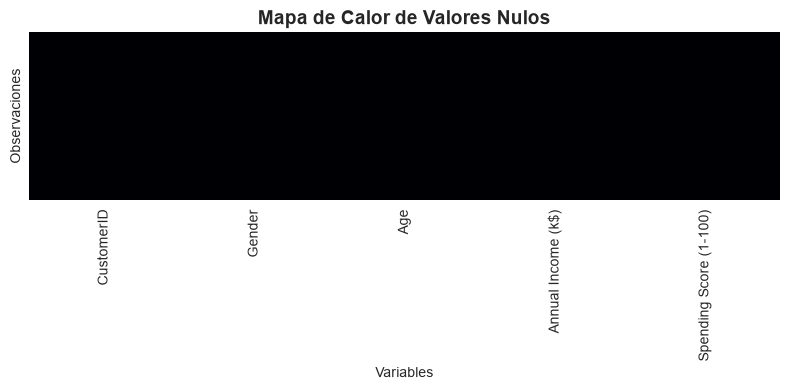

In [8]:
# Mapa de calor de valores nulos
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(data.isnull(), cmap='magma', cbar=False, yticklabels=False)
plt.title('Mapa de Calor de Valores Nulos', fontsize=14, fontweight='bold')
plt.xlabel('Variables')
plt.ylabel('Observaciones')
plt.tight_layout()
plt.show()


**Interpretación:** El mapa de calor confirma que **no existen valores nulos** en ninguna variable del dataset. Los 200 registros están completos.


In [9]:
# Verificación de registros duplicados
duplicados = data.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

# Valores únicos por columna
print("\n" + "═" * 60)
print("VALORES ÚNICOS POR COLUMNA")
print("═" * 60)
for col in data.columns:
    print(f"  {col:30s} → {data[col].nunique():4d} valores únicos")


Registros duplicados: 0

════════════════════════════════════════════════════════════
VALORES ÚNICOS POR COLUMNA
════════════════════════════════════════════════════════════
  CustomerID                     →  200 valores únicos
  Gender                         →    2 valores únicos
  Age                            →   51 valores únicos
  Annual Income (k$)             →   64 valores únicos
  Spending Score (1-100)         →   84 valores únicos


In [10]:
# Verificación de rangos y posibles inconsistencias
print("═" * 60)
print("RANGOS DE VARIABLES NUMÉRICAS")
print("═" * 60)
for col in data.select_dtypes(include='number').columns:
    print(f"  {col:30s} → Mín: {data[col].min():6.0f}  |  Máx: {data[col].max():6.0f}")

print("\n" + "═" * 60)
print("VALORES DE LA VARIABLE CATEGÓRICA 'Gender'")
print("═" * 60)
print(data['Gender'].value_counts())


════════════════════════════════════════════════════════════
RANGOS DE VARIABLES NUMÉRICAS
════════════════════════════════════════════════════════════
  CustomerID                     → Mín:      1  |  Máx:    200
  Age                            → Mín:     18  |  Máx:     70
  Annual Income (k$)             → Mín:     15  |  Máx:    137
  Spending Score (1-100)         → Mín:      1  |  Máx:     99

════════════════════════════════════════════════════════════
VALORES DE LA VARIABLE CATEGÓRICA 'Gender'
════════════════════════════════════════════════════════════
Gender
Female    112
Male       88
Name: count, dtype: int64


**Interpretación de la calidad de datos:**
- **Sin valores nulos:** Todas las columnas tienen 200 registros completos.
- **Sin registros duplicados:** No existen filas repetidas.
- **Rangos válidos:**
  - `CustomerID` va de 1 a 200 (identificador secuencial, coherente).
  - `Age` va de 18 a 70 años (rango razonable para clientes de un centro comercial).
  - `Annual Income (k$)` va de 15 a 137 mil dólares (rango plausible).
  - `Spending Score (1-100)` va de 1 a 99 (dentro del rango definido de 1 a 100).
- **Género:** Solo dos categorías (`Female`: 112, `Male`: 88), sin errores de captura ni inconsistencias.
- **Conclusión:** El dataset está limpio y listo para el análisis. No se requiere limpieza adicional.


## 5. Estadísticas Descriptivas

Se calculan las medidas de tendencia central y dispersión para las variables numéricas del dataset.


In [11]:
# Estadísticas descriptivas completas
data.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


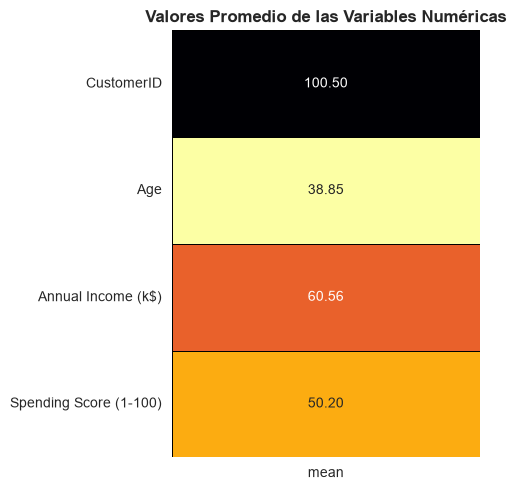

In [12]:
# Visualización de los valores promedio mediante heatmap
fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(
    data.describe().T[['mean']],
    cmap='inferno_r',
    annot=True,
    fmt='.2f',
    linecolor='black',
    linewidths=0.4,
    cbar=False
)
plt.title('Valores Promedio de las Variables Numéricas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretación de las estadísticas descriptivas:**

| Medida | Age | Annual Income (k$) | Spending Score (1-100) |
|---|---|---|---|
| **Media** | 38.85 | 60.56 | 50.20 |
| **Desv. Estándar** | 13.97 | 26.26 | 25.82 |
| **Mínimo** | 18 | 15 | 1 |
| **Q1 (25%)** | 28.75 | 41.50 | 34.75 |
| **Mediana (50%)** | 36 | 61.50 | 50.00 |
| **Q3 (75%)** | 49 | 78.00 | 73.00 |
| **Máximo** | 70 | 137 | 99 |

- La **edad promedio** de los clientes es de aproximadamente **38.85 años**, con una desviación estándar de ~14 años, lo que indica una distribución moderadamente amplia.
- El **ingreso anual promedio** es de **60.56 mil dólares**, cercano a la mediana de ingresos en EE.UU. La dispersión es alta (σ ≈ 26.26), lo que sugiere una mezcla de clientes con ingresos bajos, medios y altos.
- La **puntuación de gasto promedio** es de **50.20**, ubicada justo en el centro de la escala (1-100). La desviación estándar alta (~25.82) indica que los clientes tienen comportamientos de gasto muy variados.
- La **mediana** y la **media** son muy cercanas en las tres variables, lo que sugiere distribuciones relativamente simétricas o ligeramente sesgadas.


## 6. Análisis Exploratorio de Datos (EDA)

### 6.1 Separación de Variables Numéricas y Categóricas


In [13]:
# Separar variables por tipo
categorical_features = data.select_dtypes(include='object').columns.tolist()
numerical_features = data.select_dtypes(include='number').columns.tolist()

print(f"Variables categóricas: {categorical_features}")
print(f"Variables numéricas  : {numerical_features}")


Variables categóricas: ['Gender']
Variables numéricas  : ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


### Codificación de la variable Gender

Para poder incluir la variable `Gender` en las visualizaciones numéricas y en la matriz de correlación, se realiza una codificación numérica utilizando `LabelEncoder`. Este proceso asigna:
- **Female → 0**
- **Male → 1**

> **Importante:** Esta codificación **no implica un orden jerárquico** entre los géneros. Se trata únicamente de una transformación necesaria para que los algoritmos de Machine Learning puedan procesar la variable, ya que estos solo trabajan con valores numéricos. El valor 1 asignado a "Male" no significa que sea "mayor" o "mejor" que 0 asignado a "Female".


In [14]:
# Crear copia profunda del dataset para trabajar con la codificación
df1 = data.copy(deep=True)

# Codificación de Gender con LabelEncoder
le = LabelEncoder()
df1['Gender'] = le.fit_transform(df1['Gender'])

print("Mapeo de codificación:")
for original, encoded in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {original:8s} → {encoded}")

print("\nPrimeras filas con Gender codificado:")
df1.head()


Mapeo de codificación:
  Female   → 0
  Male     → 1

Primeras filas con Gender codificado:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


### 6.2 Distribuciones Univariadas

Se analizan las distribuciones individuales de cada variable para identificar patrones, simetría y posibles agrupaciones naturales en los datos.


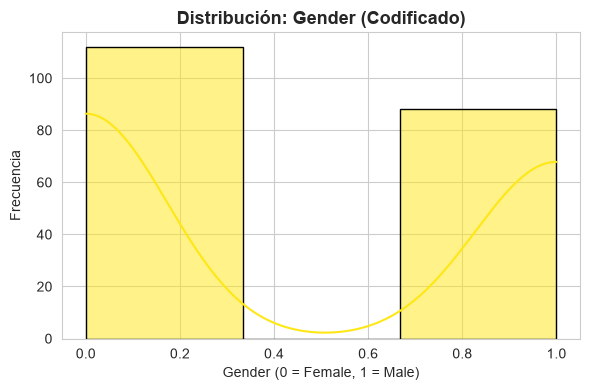

In [15]:
# Distribución de la variable categórica Gender (codificada)
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df1['Gender'], kde=True, bins=3, color='#FEE715', edgecolor='black')
plt.title('Distribución: Gender (Codificado)', fontsize=13, fontweight='bold')
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


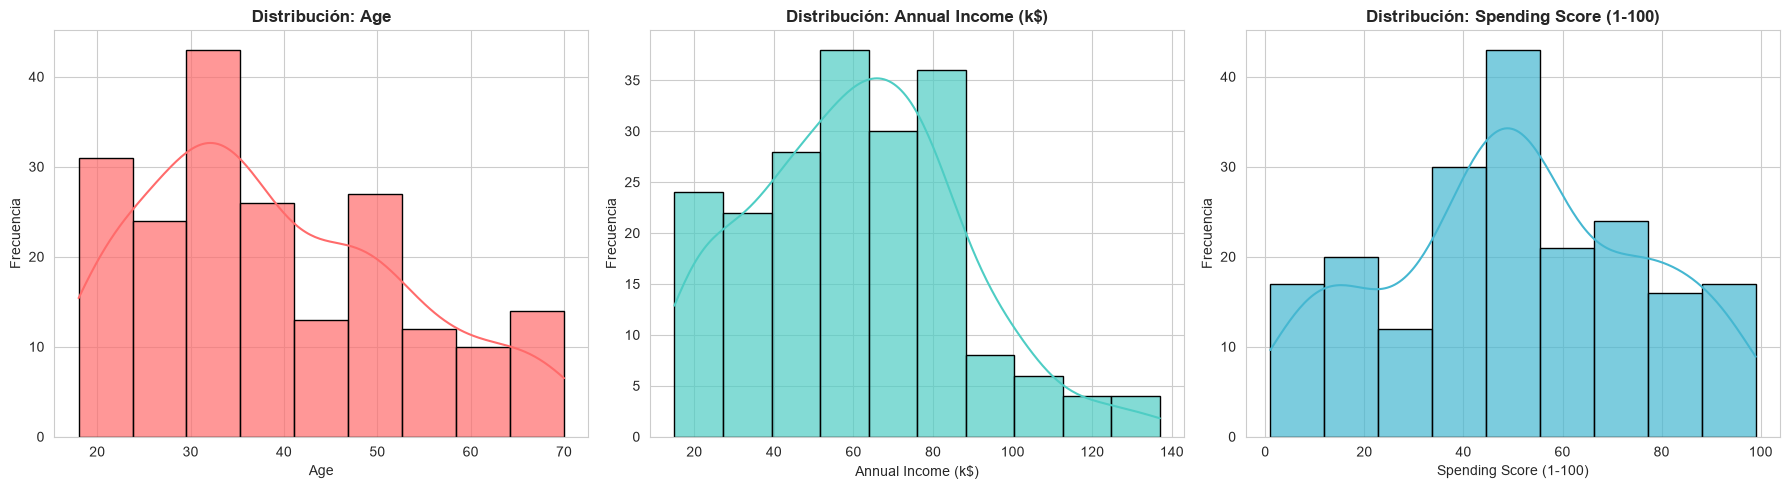

In [16]:
# Distribuciones de las variables numéricas (sin CustomerID)
num_features_plot = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, feat in enumerate(num_features_plot):
    ax = axes[i]
    sns.histplot(data[feat], kde=True, color=colors[i], edgecolor='black', alpha=0.7, ax=ax)
    ax.set_title(f'Distribución: {feat}', fontsize=12, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


**Interpretación de las distribuciones:**

- **Gender:** La distribución muestra que hay más clientas mujeres (Female = 0) que hombres (Male = 1), aunque la diferencia no es muy pronunciada. La distribución es prácticamente equilibrada.

- **Age (Edad):** La distribución presenta un **sesgo positivo (right-skewed)**, con una mayor concentración de clientes en el rango de **20 a 40 años**. Esto indica que el centro comercial atrae principalmente a un público joven y de mediana edad. La frecuencia disminuye progresivamente después de los 40 años.

- **Annual Income (k$) — Ingreso Anual:** La distribución también muestra un ligero **sesgo positivo**, con la mayor concentración de clientes en ingresos entre **40k y 80k dólares**. Hay menor representación de clientes con ingresos muy bajos (<20k) o muy altos (>100k).

- **Spending Score (1-100) — Puntuación de Gasto:** La distribución presenta un patrón interesante similar al patrón **"Head and Shoulders"** (cabeza y hombros) observado en análisis financiero. Se observan dos "hombros" alrededor de los valores 20 y 80, con la "cabeza" (mayor frecuencia) centrada entre 40 y 60. Esto sugiere que hay **tres grupos naturales** de comportamiento de gasto: bajo, medio y alto.


### 6.3 Análisis Detallado de Género


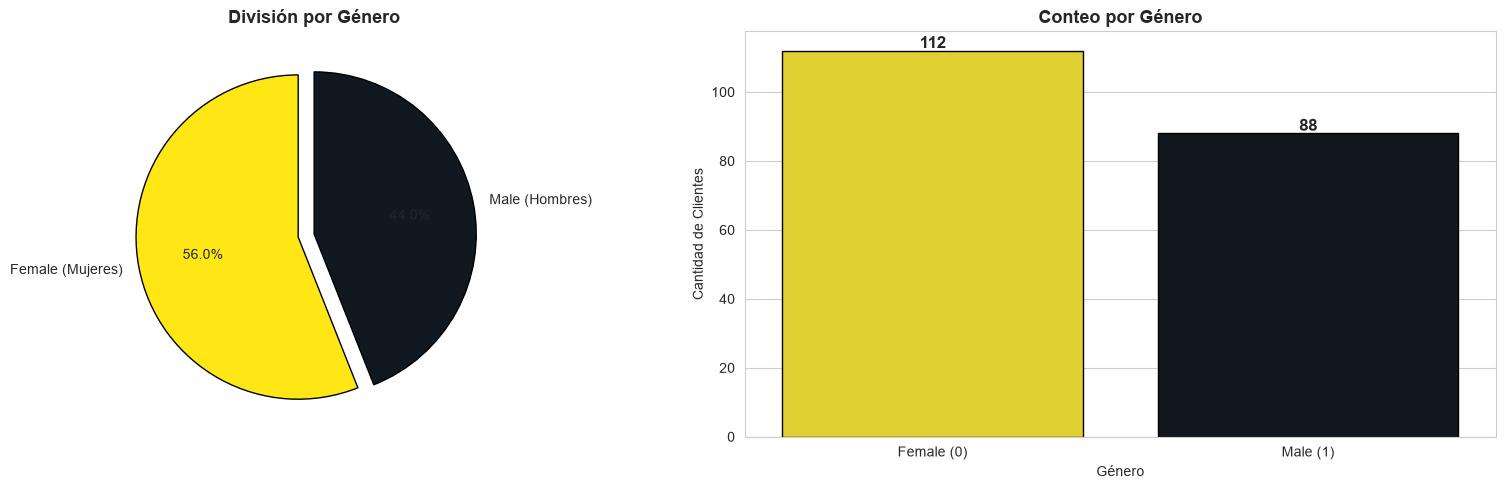

In [17]:
# Cálculos para el gráfico de pastel
conteo_genero = data['Gender'].value_counts()
colors_gender = ['#FEE715', '#101820']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

# Gráfico de pastel
ax1 = axes[0]
ax1.pie(
    conteo_genero.values,
    labels=['Female (Mujeres)', 'Male (Hombres)'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.1, 0),
    colors=colors_gender,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1, 'antialiased': True}
)
ax1.set_title('División por Género', fontsize=13, fontweight='bold')

# Gráfico de barras con conteo
ax2 = axes[1]
bars = sns.countplot(x='Gender', data=df1, palette=colors_gender, edgecolor='black', ax=ax2)
for rect in bars.patches:
    bars.text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + 0.75,
        int(rect.get_height()),
        horizontalalignment='center',
        fontsize=12,
        fontweight='bold'
    )
ax2.set_title('Conteo por Género', fontsize=13, fontweight='bold')
ax2.set_xticklabels(['Female (0)', 'Male (1)'])
ax2.set_xlabel('Género')
ax2.set_ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.show()


**Interpretación:** Del total de 200 clientes, **112 son mujeres (56%)** y **88 son hombres (44%)**. Las clientas mujeres representan una ligera mayoría en el dataset, aunque la distribución es relativamente equilibrada. Esta proporción es relevante para las estrategias de marketing del centro comercial.


## 7. Análisis de Valores Atípicos (Outliers)

Se utilizan **diagramas de caja (boxplots)** y **diagramas de violín (violinplots)** para detectar valores atípicos y analizar la distribución de cada variable numérica segmentada por género.


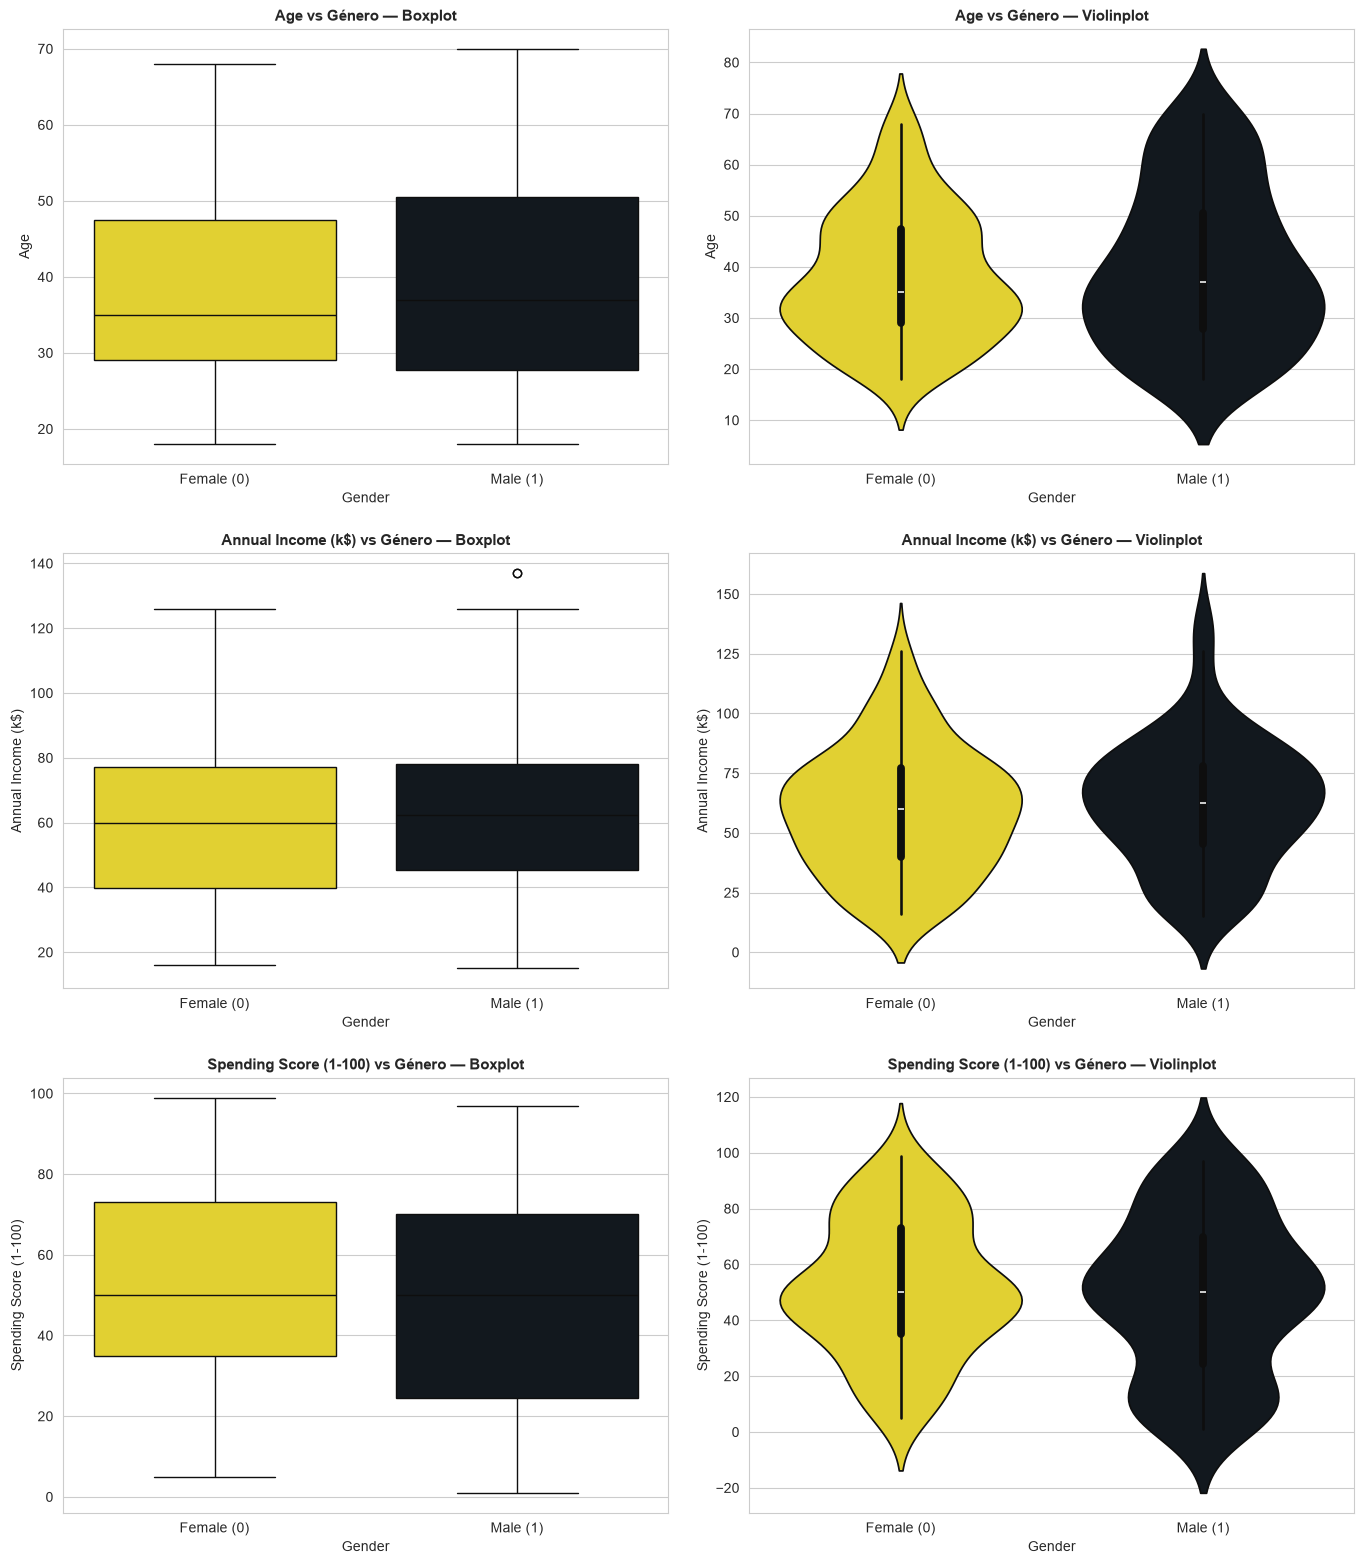

In [18]:
# Variables numéricas a analizar (sin CustomerID)
num_features_plot = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors_gender = ['#FEE715', '#101820']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 16))

for i, feat in enumerate(num_features_plot):
    # Boxplot
    ax_box = axes[i][0]
    sns.boxplot(x='Gender', y=feat, palette=colors_gender, data=df1, ax=ax_box)
    ax_box.set_xticklabels(['Female (0)', 'Male (1)'])
    ax_box.set_title(f'{feat} vs Género — Boxplot', fontsize=11, fontweight='bold')
    
    # Violinplot
    ax_vio = axes[i][1]
    sns.violinplot(x='Gender', y=feat, palette=colors_gender, data=df1, ax=ax_vio)
    ax_vio.set_xticklabels(['Female (0)', 'Male (1)'])
    ax_vio.set_title(f'{feat} vs Género — Violinplot', fontsize=11, fontweight='bold')

plt.tight_layout(pad=2)
plt.show()


**Interpretación de los valores atípicos y distribuciones por género:**

- **Edad (Age):**
  - El rango intercuartílico (IQR) de las mujeres va de ~30 a ~49 años, mientras que el de los hombres es ligeramente más amplio (~27 a ~50 años).
  - La mediana de edad es similar en ambos géneros (~36 años).
  - Los violinplots muestran una concentración notable en el rango de **30-35 años** para ambos géneros.
  - No se detectan valores atípicos significativos.

- **Ingreso Anual (Annual Income k$):**
  - La mediana del ingreso anual es cercana a **60k** para ambos géneros.
  - Los hombres presentan algunos **valores atípicos** en el extremo superior (ingresos > 100k), lo que se observa como puntos fuera de los bigotes del boxplot.
  - El violinplot del ingreso masculino muestra un estrechamiento pronunciado en los valores altos, indicando menor densidad en ese rango.

- **Puntuación de Gasto (Spending Score):**
  - Las mujeres tienen una mediana de gasto ligeramente superior a la de los hombres.
  - El violinplot femenino muestra una distribución más concentrada alrededor de la mediana, con una forma más "abultada" en el centro.
  - Los hombres muestran una distribución bimodal más marcada, con concentraciones tanto en valores bajos (0-20) como en valores medios (40-60).
  - No se detectan outliers marcados en esta variable.


## 8. Análisis Bivariado y Multivariado

Se analizan las relaciones entre pares de variables numéricas, diferenciando por género, mediante diagramas de dispersión (scatterplots).


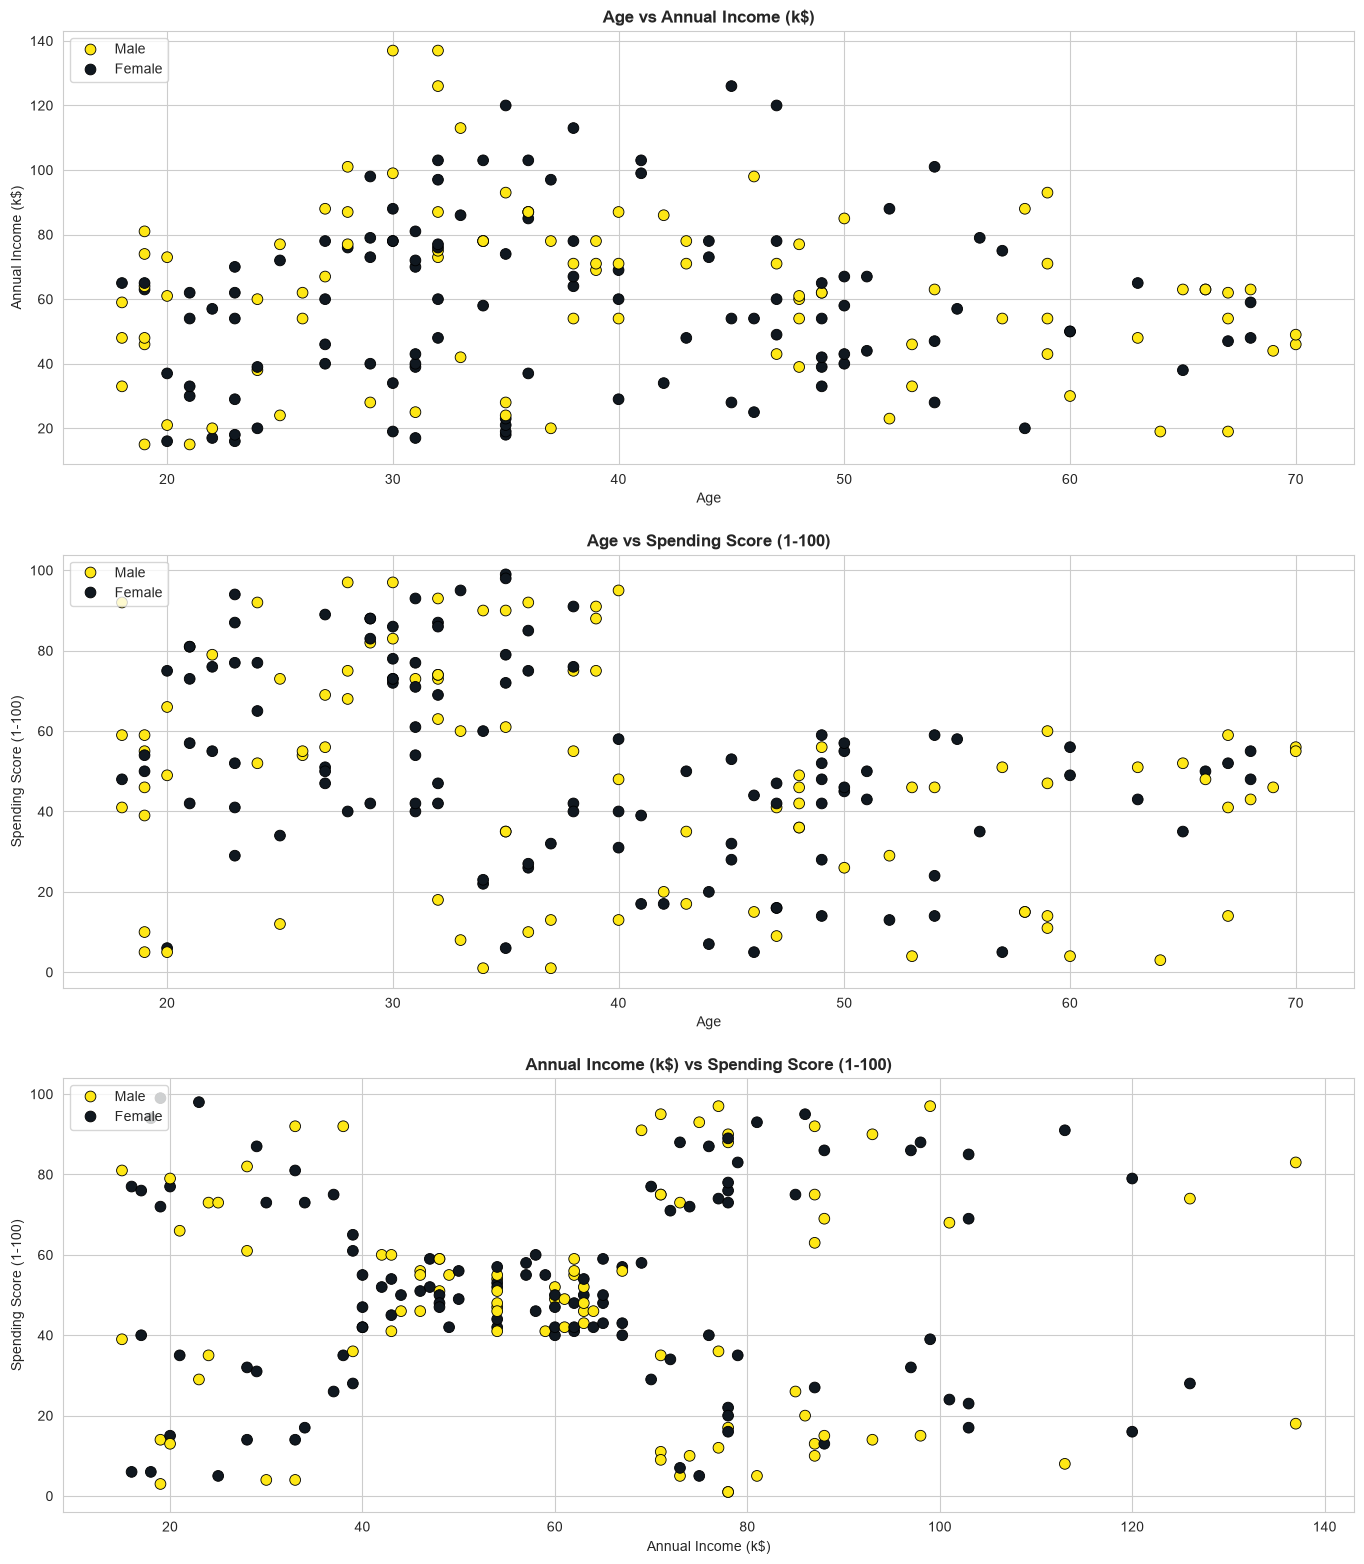

In [19]:
# Scatterplots entre pares de variables numéricas, coloreados por género
num_features_plot = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors_gender = ['#FEE715', '#101820']

a = 0
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 16))

for i in range(len(num_features_plot) - 1):
    for j in range(len(num_features_plot)):
        if i != j and j > i:
            ax = axes[a]
            sns.scatterplot(
                x=num_features_plot[i],
                y=num_features_plot[j],
                data=data,
                hue='Gender',
                palette=colors_gender,
                edgecolor='black',
                s=60,
                ax=ax
            )
            ax.legend(loc='upper left')
            ax.set_title(
                f'{num_features_plot[i]} vs {num_features_plot[j]}',
                fontsize=12, fontweight='bold'
            )
            a += 1

plt.tight_layout(pad=2)
plt.show()


**Interpretación de los diagramas de dispersión:**

1. **Edad vs Ingreso Anual:** Los puntos se distribuyen de forma bastante uniforme sin un patrón claro de correlación. El género no proporciona información significativa de separación. Los clientes de todas las edades presentan ingresos variados.

2. **Edad vs Puntuación de Gasto:** Se observa una tendencia interesante:
   - Los clientes **jóvenes (20-30 años)** muestran una gran variabilidad en su puntuación de gasto, con valores tanto muy altos como muy bajos.
   - Los clientes de **edad media (30-40 años)** exhiben ambos extremos del gasto.
   - Los clientes **mayores (40-70 años)** tienden a tener puntuaciones de gasto **más bajas** (concentradas en el rango 0-40), lo que sugiere un comportamiento de gasto más conservador.

3. **Ingreso Anual vs Puntuación de Gasto:** Este es el gráfico más revelador — se pueden observar claramente **5 grupos distintos**:
   - **Grupo 1** (bajo ingreso, bajo gasto): esquina inferior izquierda.
   - **Grupo 2** (bajo ingreso, alto gasto): esquina superior izquierda.
   - **Grupo 3** (ingreso medio, gasto medio): centro del gráfico.
   - **Grupo 4** (alto ingreso, bajo gasto): esquina inferior derecha.
   - **Grupo 5** (alto ingreso, alto gasto): esquina superior derecha.
   
   Esta distribución hace que la combinación **Ingreso Anual — Puntuación de Gasto** sea la candidata ideal para la segmentación con K-Means.


## 9. Resumen del Análisis Exploratorio (EDA)

A partir del análisis realizado, se identifican los siguientes hallazgos clave:

- Las clientas **mujeres** superan ligeramente en número a los hombres (56% vs 44%). La distribución de **género** es relativamente equilibrada y no muestra una diferencia significativa en las demás variables.

- Los clientes del centro comercial pueden dividirse en **grupos de edad**:
  - **20-30 años** (jóvenes)
  - **30-40 años** (adultos jóvenes)
  - **40-70 años** (adultos mayores)

- La mediana del **ingreso anual** es de aproximadamente **60k dólares** para ambos géneros. Se observan 3 rangos naturales: **0-40k**, **40-70k** y **70-140k**.

- La **puntuación de gasto** de las mujeres es ligeramente superior a la de los hombres. También se pueden identificar 3 grupos: **0-40** (bajo), **40-60** (medio) y **60-100** (alto).

- La combinación más prometedora para la segmentación es **Ingreso Anual vs Puntuación de Gasto**, donde se visualizan claramente 5 clústeres potenciales.

- Mediante la combinación de estas variables, los clientes del centro comercial pueden ser **segmentados** para diseñar estrategias de marketing personalizadas.


## 10. Ingeniería de Características (Feature Engineering)

### 10.1 Matriz de Correlación

La matriz de correlación permite identificar relaciones lineales entre las variables numéricas. Valores cercanos a **+1** indican una correlación positiva fuerte, valores cercanos a **-1** indican una correlación negativa fuerte, y valores cercanos a **0** indican ausencia de correlación lineal.


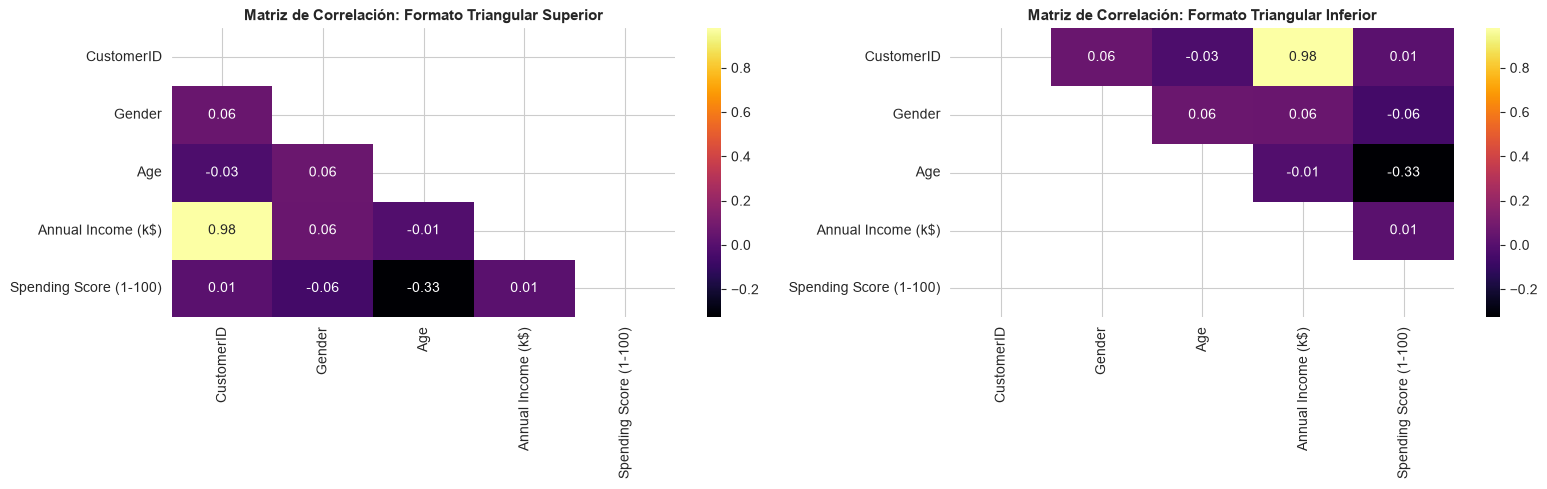

Columna 'CustomerID' eliminada del dataset de trabajo.


In [20]:
# Matrices de correlación (triangular superior e inferior)
ut = np.triu(df1.corr(numeric_only=True))
lt = np.tril(df1.corr(numeric_only=True))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

# Triangular superior
ax1 = axes[0]
sns.heatmap(
    df1.corr(numeric_only=True), cmap='inferno', annot=True,
    fmt='.2f', cbar=True, mask=ut, ax=ax1
)
ax1.set_title('Matriz de Correlación: Formato Triangular Superior', fontsize=11, fontweight='bold')

# Triangular inferior
ax2 = axes[1]
sns.heatmap(
    df1.corr(numeric_only=True), cmap='inferno', annot=True,
    fmt='.2f', cbar=True, mask=lt, ax=ax2
)
ax2.set_title('Matriz de Correlación: Formato Triangular Inferior', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Eliminar CustomerID (no es útil para el modelado)
df1.drop(columns='CustomerID', inplace=True)
print("Columna 'CustomerID' eliminada del dataset de trabajo.")


**Interpretación de la matriz de correlación:**

- Ambas matrices muestran la misma información; se presentan en dos formatos (triangular superior e inferior) como técnica de visualización útil cuando el dataset tiene muchas variables.
- **CustomerID** muestra una alta correlación positiva con **Annual Income (k$)** únicamente porque los clientes están ordenados de forma ascendente por ingreso. Esta correlación es **espuria** (no tiene significado real), por lo que se elimina `CustomerID` del análisis.
- **Gender** no muestra correlación significativa con ninguna otra variable — los valores están cercanos a 0.
- **Spending Score** y **Age** presentan una **correlación negativa moderada** (≈ -0.33), lo que indica que a mayor edad, la puntuación de gasto tiende a ser menor.
- No existen problemas de **multicolinealidad** entre las variables predictoras.


### 10.2 Normalización de los Datos (Data Scaling)

Los modelos de Machine Learning no comprenden las unidades de las variables; simplemente tratan los valores como números. Si una variable tiene un rango mucho mayor que otra (por ejemplo, ingreso anual de 15-137 vs edad de 18-70), el algoritmo podría dar **mayor peso** a la variable con valores más grandes, distorsionando los resultados.

La **normalización** transforma los valores de cada variable al rango **[0, 1]** utilizando `MinMaxScaler`, de tal forma que:

$$x_{normalizado} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Se crea una **copia profunda** del dataset (`df2`) para aplicar la normalización, de modo que podamos comparar los resultados del modelado con datos originales (`df1`) y normalizados (`df2`).


In [21]:
# Crear copia profunda del dataset para normalización
df2 = df1.copy(deep=True)

# Aplicar MinMaxScaler (normalización al rango [0, 1])
mms = MinMaxScaler()

df2['Age'] = mms.fit_transform(df2[['Age']])
df2['Annual Income (k$)'] = mms.fit_transform(df2[['Annual Income (k$)']])
df2['Spending Score (1-100)'] = mms.fit_transform(df2[['Spending Score (1-100)']])

print("Dataset ORIGINAL (df1) — Primeras 5 filas:")
print(df1.head())
print()
print("Dataset NORMALIZADO (df2) — Primeras 5 filas:")
print(df2.head())


Dataset ORIGINAL (df1) — Primeras 5 filas:
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       1   19                  15                      39
1       1   21                  15                      81
2       0   20                  16                       6
3       0   23                  16                      77
4       0   31                  17                      40

Dataset NORMALIZADO (df2) — Primeras 5 filas:
   Gender       Age  Annual Income (k$)  Spending Score (1-100)
0       1  0.019231            0.000000                0.387755
1       1  0.057692            0.000000                0.816327
2       0  0.038462            0.008197                0.051020
3       0  0.096154            0.008197                0.775510
4       0  0.250000            0.016393                0.397959


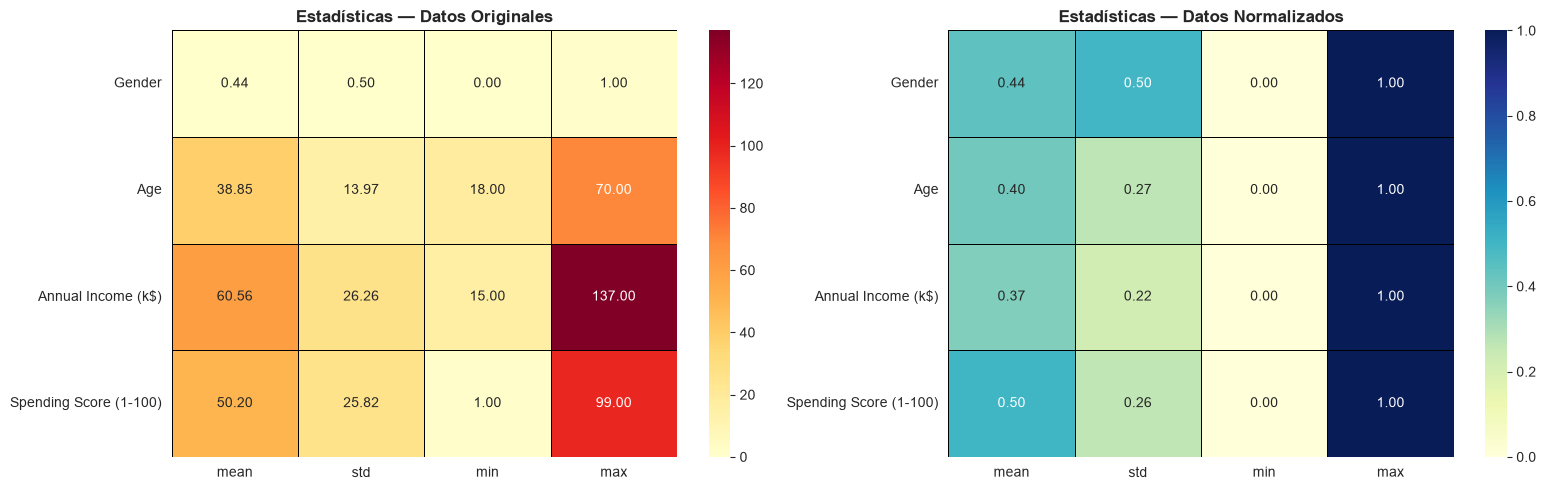

In [22]:
# Comparación visual: datos originales vs normalizados
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

# Datos originales
ax1 = axes[0]
sns.heatmap(
    df1.describe().T[['mean', 'std', 'min', 'max']],
    cmap='YlOrRd', annot=True, fmt='.2f',
    linecolor='black', linewidths=0.4, ax=ax1
)
ax1.set_title('Estadísticas — Datos Originales', fontsize=12, fontweight='bold')

# Datos normalizados
ax2 = axes[1]
sns.heatmap(
    df2.describe().T[['mean', 'std', 'min', 'max']],
    cmap='YlGnBu', annot=True, fmt='.2f',
    linecolor='black', linewidths=0.4, ax=ax2
)
ax2.set_title('Estadísticas — Datos Normalizados', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


**Interpretación de la normalización:**

Tras aplicar `MinMaxScaler`, las tres variables numéricas (`Age`, `Annual Income`, `Spending Score`) ahora tienen valores en el rango **[0, 1]**:
- Los valores mínimos de cada variable se transformaron a **0**.
- Los valores máximos se transformaron a **1** (o cercanos a 1).
- La variable `Gender` (ya codificada como 0/1) no necesitó normalización adicional.

Ahora ambas versiones del dataset están listas para el modelado. Pasaremos a construir y comparar los modelos K-Means con ambas versiones.


## 11. Modelado con K-Means

### Fundamentos del Algoritmo K-Means

**K-Means** es el algoritmo de agrupamiento más popular para problemas de aprendizaje no supervisado. Su funcionamiento se resume en los siguientes pasos:

1. **Inicialización:** Se seleccionan **k** centroides de forma aleatoria (o con la técnica k-means++).
2. **Asignación:** Cada punto de datos se asigna al centroide más cercano (según la distancia euclidiana).
3. **Actualización:** Se recalculan los centroides como el promedio de los puntos asignados a cada clúster.
4. **Iteración:** Los pasos 2 y 3 se repiten hasta que los centroides converjan (no cambien significativamente) o se alcance el número máximo de iteraciones.

### Selección del Hiperparámetro k

El parámetro **k** define cuántos clústeres se crearán. Para seleccionar el valor óptimo, se utilizan dos métodos estadísticos:

- **Método del Codo (Elbow Method):** Grafica la **inercia** (suma de distancias al cuadrado de cada punto a su centroide, WCSS) para diferentes valores de k. El punto donde la curva forma un "codo" — es decir, donde la reducción de la inercia comienza a ser marginal — indica el número óptimo de clústeres.

- **Coeficiente de Silueta (Silhouette Score):** Evalúa qué tan bien definidos están los clústeres. Sus valores van de **-1 a 1**:
  - **Cercano a 1:** Los puntos están bien asignados a su clúster.
  - **Cercano a 0:** Los puntos están en la frontera entre clústeres.
  - **Negativo:** Los puntos probablemente fueron asignados al clúster incorrecto.
  - Se busca el valor de **k** que **maximice** el coeficiente de silueta.

> **Nota:** K-Means **no soporta variables categóricas**, por lo que la columna `Gender` se eliminará antes del modelado.


In [23]:
# Eliminar la variable categórica Gender para el modelado
df1.drop(columns='Gender', inplace=True)
df2.drop(columns='Gender', inplace=True)

print("Columnas en df1 (original)   :", list(df1.columns))
print("Columnas en df2 (normalizado):", list(df2.columns))
print("\nVariable 'Gender' eliminada de ambos datasets. Listos para modelado.")


Columnas en df1 (original)   : ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Columnas en df2 (normalizado): ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Variable 'Gender' eliminada de ambos datasets. Listos para modelado.


---

### <center>Combinación 1: Edad — Ingreso Anual (k$)</center>

Se extraen las columnas `Age` y `Annual Income (k$)` como matrices de características para ambos datasets.


In [24]:
m1 = df1[['Age', 'Annual Income (k$)']].values  # Dataset Original
m2 = df2[['Age', 'Annual Income (k$)']].values  # Dataset Normalizado

print(f"Forma de m1 (original)    : {m1.shape}")
print(f"Forma de m2 (normalizado) : {m2.shape}")
print(f"\nEjemplo m1 (primeras 3 filas):\n{m1[:3]}")
print(f"\nEjemplo m2 (primeras 3 filas):\n{m2[:3]}")


Forma de m1 (original)    : (200, 2)
Forma de m2 (normalizado) : (200, 2)

Ejemplo m1 (primeras 3 filas):
[[19 15]
 [21 15]
 [20 16]]

Ejemplo m2 (primeras 3 filas):
[[0.01923077 0.        ]
 [0.05769231 0.        ]
 [0.03846154 0.00819672]]


#### Dataset Original — Método del Codo y Coeficiente de Silueta


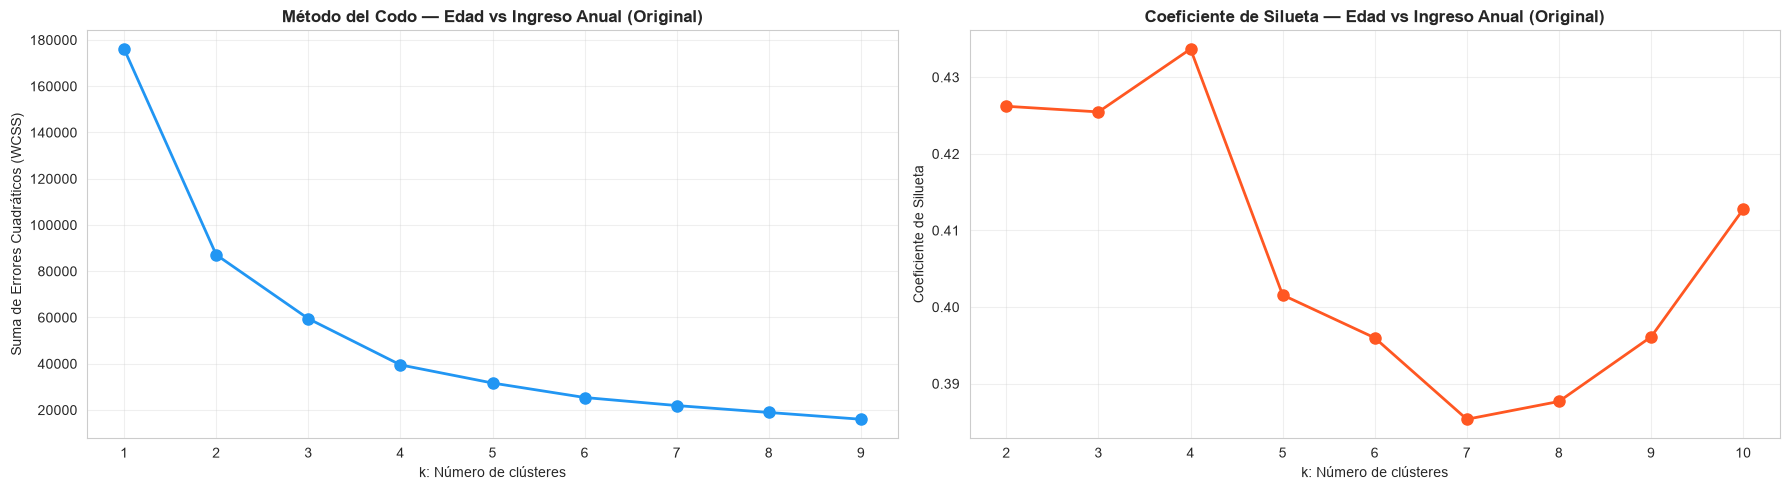


Valores de silueta: {2: '0.4262', 3: '0.4255', 4: '0.4337', 5: '0.4016', 6: '0.3960', 7: '0.3854', 8: '0.3877', 9: '0.3961', 10: '0.4127'}


In [25]:
sse = {}; sil = []; kmax = 10

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Método del Codo
ax1 = axes[0]
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000, n_init=10, random_state=42).fit(m1)
    sse[k] = kmeans.inertia_
ax1.plot(list(sse.keys()), list(sse.values()), 'o-', color='#2196F3', linewidth=2, markersize=8)
ax1.set_title('Método del Codo — Edad vs Ingreso Anual (Original)', fontsize=12, fontweight='bold')
ax1.set_xlabel('k: Número de clústeres')
ax1.set_ylabel('Suma de Errores Cuadráticos (WCSS)')
ax1.grid(True, alpha=0.3)

# Coeficiente de Silueta
ax2 = axes[1]
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric='euclidean'))
ax2.plot(range(2, kmax + 1), sil, 'o-', color='#FF5722', linewidth=2, markersize=8)
ax2.set_title('Coeficiente de Silueta — Edad vs Ingreso Anual (Original)', fontsize=12, fontweight='bold')
ax2.set_xlabel('k: Número de clústeres')
ax2.set_ylabel('Coeficiente de Silueta')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nValores de silueta: {dict(zip(range(2, kmax+1), [f'{s:.4f}' for s in sil]))}")


**Interpretación:**
- El **método del codo** muestra un quiebre notable en **k = 4**, donde la reducción de la inercia comienza a ser menos pronunciada.
- El **coeficiente de silueta** alcanza su valor máximo alrededor de **k = 4**, confirmando que 4 clústeres proporcionan la mejor separación para esta combinación de variables.
- **Selección: k = 4 clústeres.**


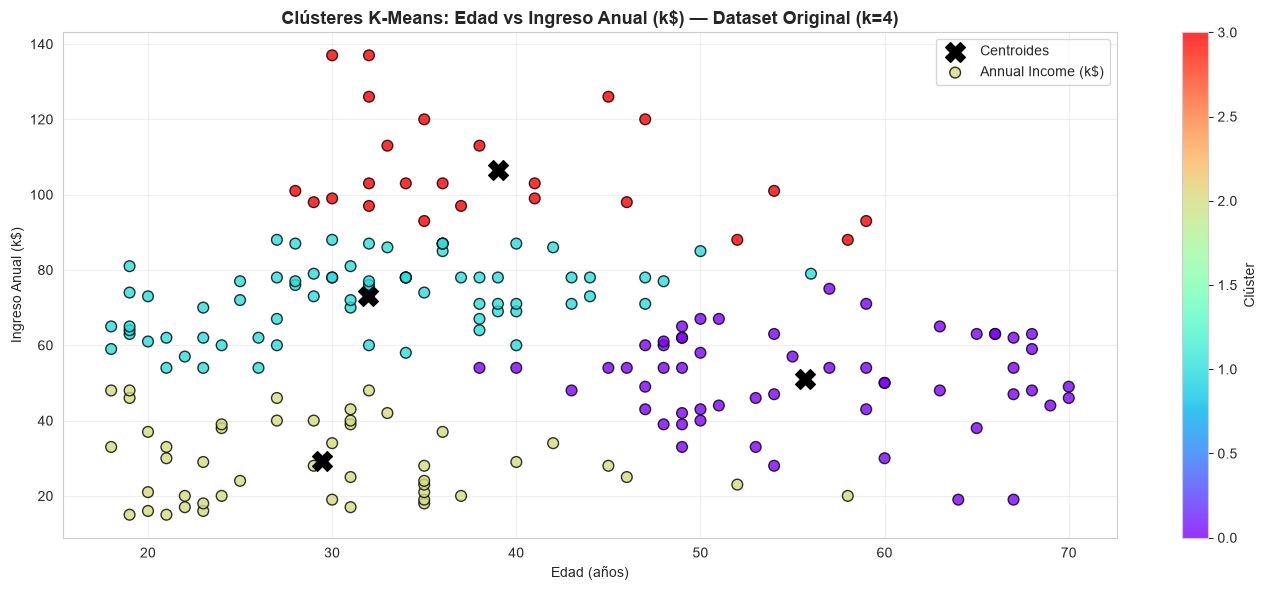

════════════════════════════════════════════════════════════
REPORTE TÉCNICO DEL MODELO — Combinación 1 (Original)
════════════════════════════════════════════════════════════
  Número de clústeres (k)  : 4
  Inercia (WCSS)           : 39502.78
  Iteraciones realizadas   : 6
  Algoritmo                : lloyd
  n_init                   : 10
  max_iter                 : 1000
  Centroides:
[[ 55.66071429  51.01785714]
 [ 31.95890411  72.95890411]
 [ 29.44680851  29.21276596]
 [ 39.         106.5       ]]


In [26]:
# Entrenamiento del modelo K-Means con k=4 — Dataset Original
model = KMeans(n_clusters=4, max_iter=1000, n_init=10, random_state=42)
model.fit(m1)
centroids = np.array(model.cluster_centers_)
labels = model.labels_

# Visualización de los clústeres
plt.figure(figsize=(14, 6))
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='black', zorder=5, label='Centroides')
scatter = plt.scatter(
    x='Age', y='Annual Income (k$)', c=labels, cmap='rainbow',
    data=df1, edgecolor='black', s=60, alpha=0.8
)
plt.colorbar(scatter, label='Clúster')
plt.title('Clústeres K-Means: Edad vs Ingreso Anual (k$) — Dataset Original (k=4)', fontsize=13, fontweight='bold')
plt.xlabel('Edad (años)')
plt.ylabel('Ingreso Anual (k$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Reporte técnico del modelo
print("═" * 60)
print("REPORTE TÉCNICO DEL MODELO — Combinación 1 (Original)")
print("═" * 60)
print(f"  Número de clústeres (k)  : {model.n_clusters}")
print(f"  Inercia (WCSS)           : {model.inertia_:.2f}")
print(f"  Iteraciones realizadas   : {model.n_iter_}")
print(f"  Algoritmo                : {model.algorithm}")
print(f"  n_init                   : {model.n_init}")
print(f"  max_iter                 : {model.max_iter}")
print(f"  Centroides:\n{centroids}")


#### Dataset Normalizado — Método del Codo y Coeficiente de Silueta


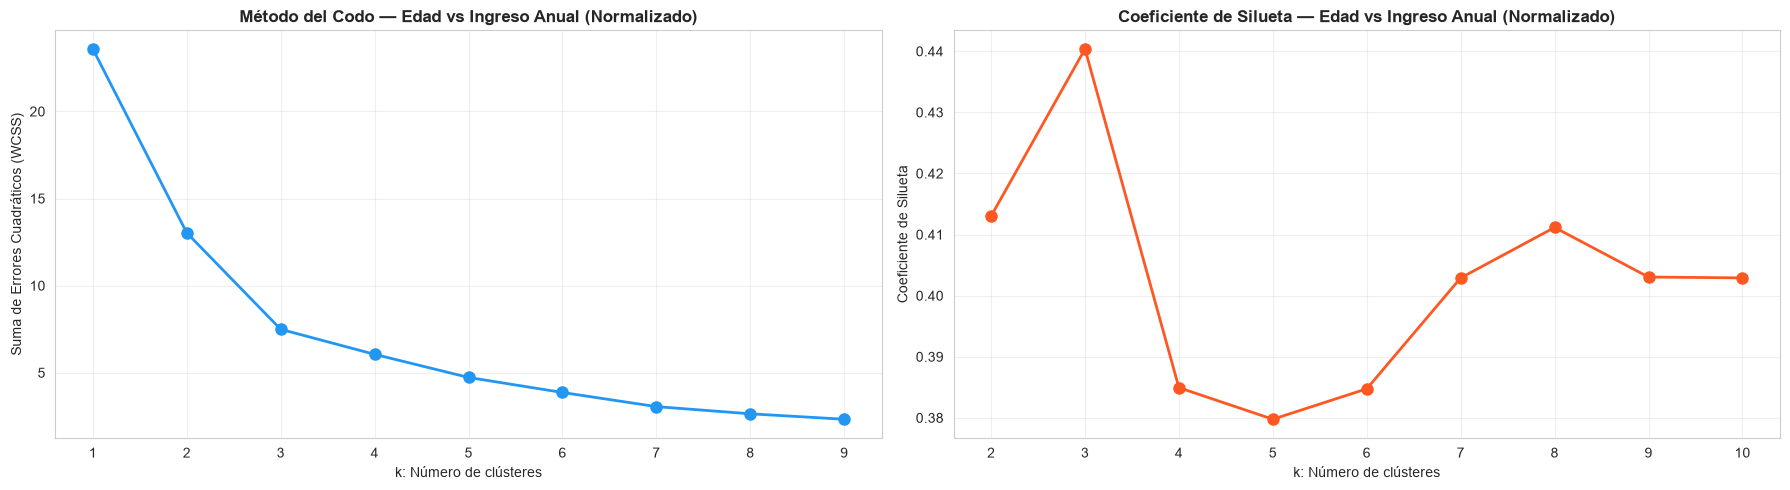


Valores de silueta: {2: '0.4130', 3: '0.4404', 4: '0.3849', 5: '0.3798', 6: '0.3847', 7: '0.4029', 8: '0.4112', 9: '0.4030', 10: '0.4029'}


In [27]:
sse = {}; sil = []; kmax = 10

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Método del Codo
ax1 = axes[0]
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000, n_init=10, random_state=42).fit(m2)
    sse[k] = kmeans.inertia_
ax1.plot(list(sse.keys()), list(sse.values()), 'o-', color='#2196F3', linewidth=2, markersize=8)
ax1.set_title('Método del Codo — Edad vs Ingreso Anual (Normalizado)', fontsize=12, fontweight='bold')
ax1.set_xlabel('k: Número de clústeres')
ax1.set_ylabel('Suma de Errores Cuadráticos (WCSS)')
ax1.grid(True, alpha=0.3)

# Coeficiente de Silueta
ax2 = axes[1]
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric='euclidean'))
ax2.plot(range(2, kmax + 1), sil, 'o-', color='#FF5722', linewidth=2, markersize=8)
ax2.set_title('Coeficiente de Silueta — Edad vs Ingreso Anual (Normalizado)', fontsize=12, fontweight='bold')
ax2.set_xlabel('k: Número de clústeres')
ax2.set_ylabel('Coeficiente de Silueta')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nValores de silueta: {dict(zip(range(2, kmax+1), [f'{s:.4f}' for s in sil]))}")


**Interpretación:**
- Con los datos normalizados, el **método del codo** sugiere un codo en **k = 3**, ya que la inercia se estabiliza a partir de ese punto.
- El **coeficiente de silueta** es más alto en **k = 3**, indicando clústeres mejor definidos que con otros valores de k.
- La normalización cambió el resultado respecto al dataset original (de k=4 a k=3), lo cual demuestra que el escalamiento de los datos puede influir en la segmentación.
- **Selección: k = 3 clústeres.**


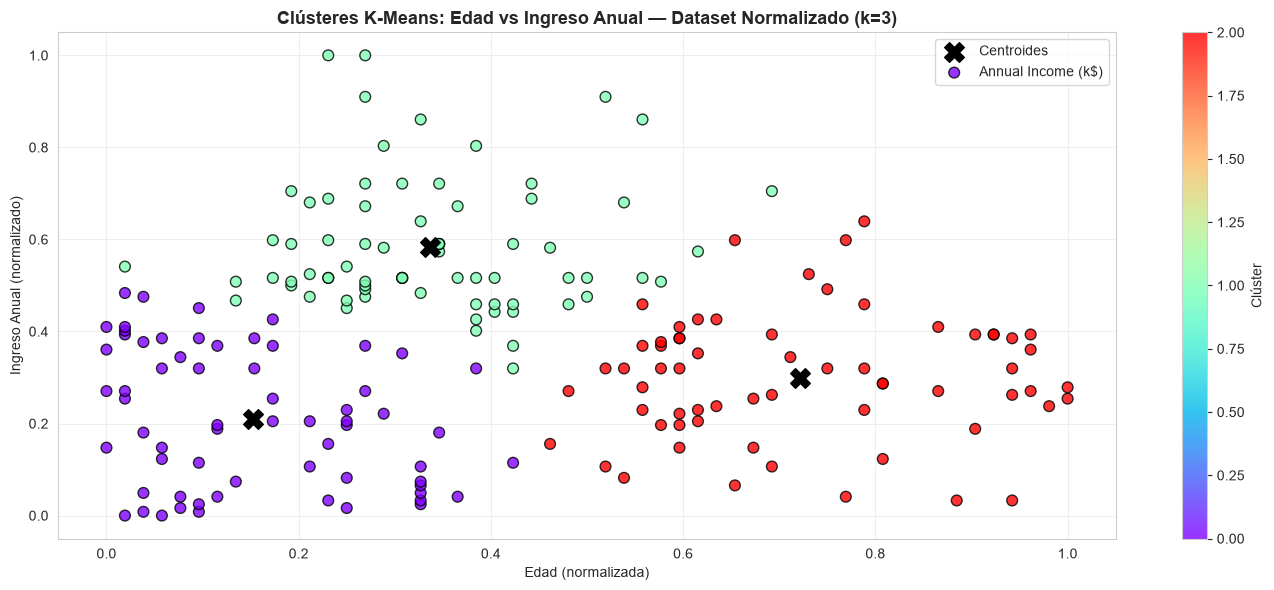

════════════════════════════════════════════════════════════
REPORTE TÉCNICO DEL MODELO — Combinación 1 (Normalizado)
════════════════════════════════════════════════════════════
  Número de clústeres (k)  : 3
  Inercia (WCSS)           : 7.4930
  Iteraciones realizadas   : 8
  Algoritmo                : lloyd
  n_init                   : 10
  max_iter                 : 1000
  Centroides:
[[0.15264423 0.21016906]
 [0.33653846 0.58435792]
 [0.72175481 0.29943648]]


In [28]:
# Entrenamiento del modelo K-Means con k=3 — Dataset Normalizado
model = KMeans(n_clusters=3, max_iter=1000, n_init=10, random_state=42)
model.fit(m2)
centroids = np.array(model.cluster_centers_)
labels = model.labels_

# Visualización de los clústeres
plt.figure(figsize=(14, 6))
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='black', zorder=5, label='Centroides')
scatter = plt.scatter(
    x='Age', y='Annual Income (k$)', c=labels, cmap='rainbow',
    data=df2, edgecolor='black', s=60, alpha=0.8
)
plt.colorbar(scatter, label='Clúster')
plt.title('Clústeres K-Means: Edad vs Ingreso Anual — Dataset Normalizado (k=3)', fontsize=13, fontweight='bold')
plt.xlabel('Edad (normalizada)')
plt.ylabel('Ingreso Anual (normalizado)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Reporte técnico del modelo
print("═" * 60)
print("REPORTE TÉCNICO DEL MODELO — Combinación 1 (Normalizado)")
print("═" * 60)
print(f"  Número de clústeres (k)  : {model.n_clusters}")
print(f"  Inercia (WCSS)           : {model.inertia_:.4f}")
print(f"  Iteraciones realizadas   : {model.n_iter_}")
print(f"  Algoritmo                : {model.algorithm}")
print(f"  n_init                   : {model.n_init}")
print(f"  max_iter                 : {model.max_iter}")
print(f"  Centroides:\n{centroids}")


---

### <center>Combinación 2: Edad — Puntuación de Gasto (Spending Score)</center>


In [29]:
m1 = df1[['Age', 'Spending Score (1-100)']].values  # Dataset Original
m2 = df2[['Age', 'Spending Score (1-100)']].values  # Dataset Normalizado

print(f"Forma de m1 (original)    : {m1.shape}")
print(f"Forma de m2 (normalizado) : {m2.shape}")


Forma de m1 (original)    : (200, 2)
Forma de m2 (normalizado) : (200, 2)


#### Dataset Original — Método del Codo y Coeficiente de Silueta


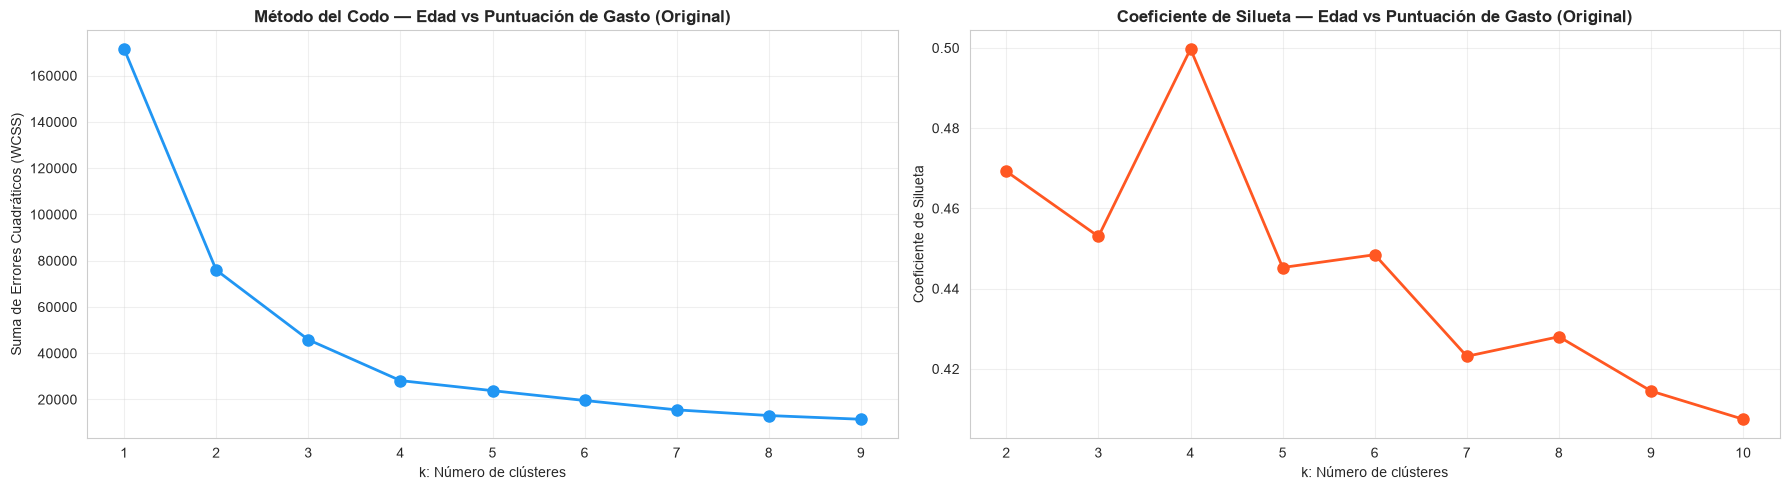


Valores de silueta: {2: '0.4692', 3: '0.4530', 4: '0.4997', 5: '0.4453', 6: '0.4485', 7: '0.4231', 8: '0.4280', 9: '0.4145', 10: '0.4074'}


In [30]:
sse = {}; sil = []; kmax = 10

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

ax1 = axes[0]
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000, n_init=10, random_state=42).fit(m1)
    sse[k] = kmeans.inertia_
ax1.plot(list(sse.keys()), list(sse.values()), 'o-', color='#2196F3', linewidth=2, markersize=8)
ax1.set_title('Método del Codo — Edad vs Puntuación de Gasto (Original)', fontsize=12, fontweight='bold')
ax1.set_xlabel('k: Número de clústeres')
ax1.set_ylabel('Suma de Errores Cuadráticos (WCSS)')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric='euclidean'))
ax2.plot(range(2, kmax + 1), sil, 'o-', color='#FF5722', linewidth=2, markersize=8)
ax2.set_title('Coeficiente de Silueta — Edad vs Puntuación de Gasto (Original)', fontsize=12, fontweight='bold')
ax2.set_xlabel('k: Número de clústeres')
ax2.set_ylabel('Coeficiente de Silueta')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nValores de silueta: {dict(zip(range(2, kmax+1), [f'{s:.4f}' for s in sil]))}")


**Interpretación:**
- El **método del codo** presenta un quiebre visible alrededor de **k = 4**.
- El **coeficiente de silueta** muestra un pico en **k = 4**, indicando buena separación entre clústeres.
- **Selección: k = 4 clústeres.**


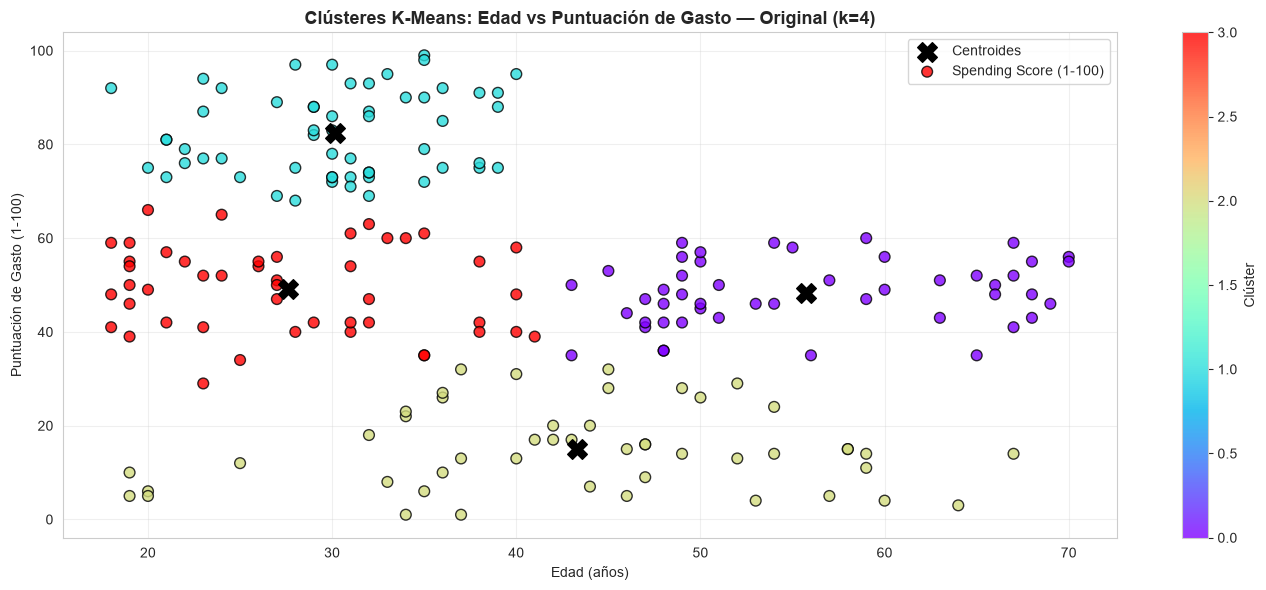

════════════════════════════════════════════════════════════
REPORTE TÉCNICO — Combinación 2 (Original)
════════════════════════════════════════════════════════════
  Número de clústeres (k)  : 4
  Inercia (WCSS)           : 28165.58
  Iteraciones realizadas   : 8
  Centroides:
[[55.70833333 48.22916667]
 [30.1754386  82.35087719]
 [43.29166667 15.02083333]
 [27.61702128 49.14893617]]


In [31]:
# Modelo K-Means con k=4 — Edad vs Spending Score (Original)
model = KMeans(n_clusters=4, max_iter=1000, n_init=10, random_state=42)
model.fit(m1)
centroids = np.array(model.cluster_centers_)
labels = model.labels_

plt.figure(figsize=(14, 6))
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='black', zorder=5, label='Centroides')
scatter = plt.scatter(
    x='Age', y='Spending Score (1-100)', c=labels, cmap='rainbow',
    data=df1, edgecolor='black', s=60, alpha=0.8
)
plt.colorbar(scatter, label='Clúster')
plt.title('Clústeres K-Means: Edad vs Puntuación de Gasto — Original (k=4)', fontsize=13, fontweight='bold')
plt.xlabel('Edad (años)')
plt.ylabel('Puntuación de Gasto (1-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("═" * 60)
print("REPORTE TÉCNICO — Combinación 2 (Original)")
print("═" * 60)
print(f"  Número de clústeres (k)  : {model.n_clusters}")
print(f"  Inercia (WCSS)           : {model.inertia_:.2f}")
print(f"  Iteraciones realizadas   : {model.n_iter_}")
print(f"  Centroides:\n{centroids}")


#### Dataset Normalizado — Método del Codo y Coeficiente de Silueta


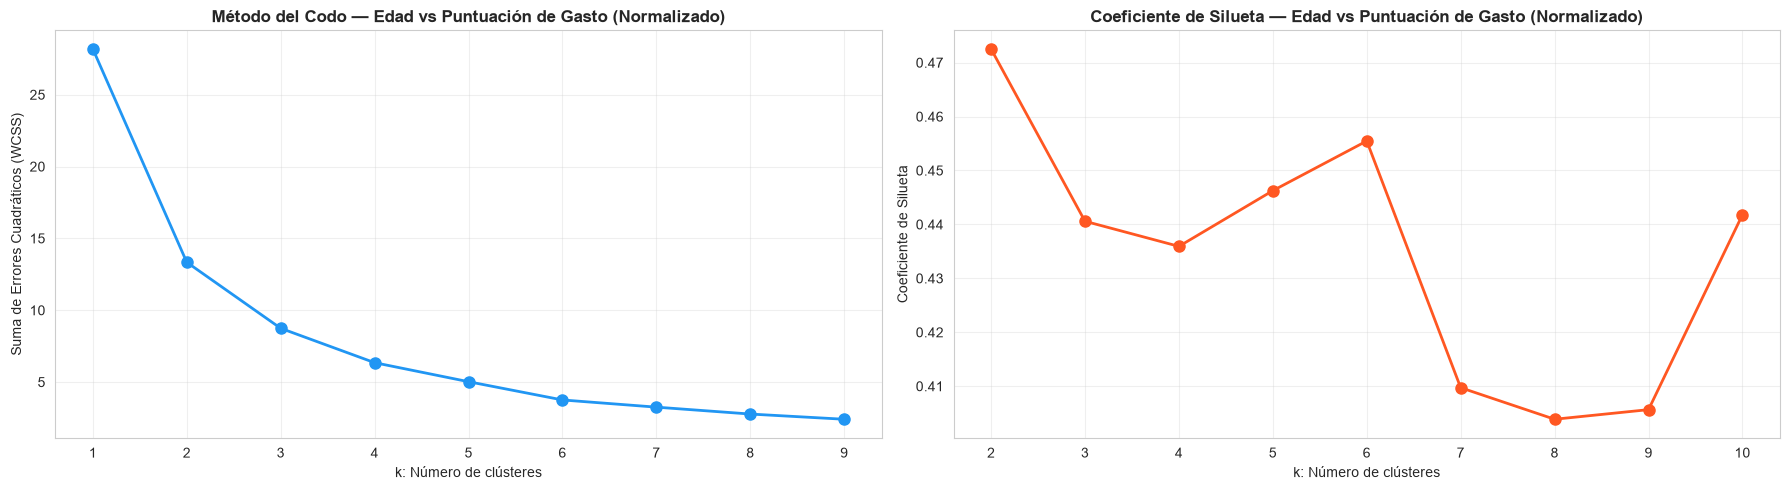


Valores de silueta: {2: '0.4725', 3: '0.4406', 4: '0.4359', 5: '0.4463', 6: '0.4555', 7: '0.4097', 8: '0.4039', 9: '0.4056', 10: '0.4418'}


In [32]:
sse = {}; sil = []; kmax = 10

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

ax1 = axes[0]
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000, n_init=10, random_state=42).fit(m2)
    sse[k] = kmeans.inertia_
ax1.plot(list(sse.keys()), list(sse.values()), 'o-', color='#2196F3', linewidth=2, markersize=8)
ax1.set_title('Método del Codo — Edad vs Puntuación de Gasto (Normalizado)', fontsize=12, fontweight='bold')
ax1.set_xlabel('k: Número de clústeres')
ax1.set_ylabel('Suma de Errores Cuadráticos (WCSS)')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric='euclidean'))
ax2.plot(range(2, kmax + 1), sil, 'o-', color='#FF5722', linewidth=2, markersize=8)
ax2.set_title('Coeficiente de Silueta — Edad vs Puntuación de Gasto (Normalizado)', fontsize=12, fontweight='bold')
ax2.set_xlabel('k: Número de clústeres')
ax2.set_ylabel('Coeficiente de Silueta')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nValores de silueta: {dict(zip(range(2, kmax+1), [f'{s:.4f}' for s in sil]))}")


**Interpretación:**
- Con datos normalizados, el **método del codo** presenta un quiebre alrededor de **k = 6**.
- El **coeficiente de silueta** muestra que **k = 6** ofrece buena separación entre los grupos.
- La normalización produce más clústeres (6 vs 4) porque al igualar las escalas de las variables, el algoritmo puede detectar subdivisiones más finas.
- **Selección: k = 6 clústeres.**


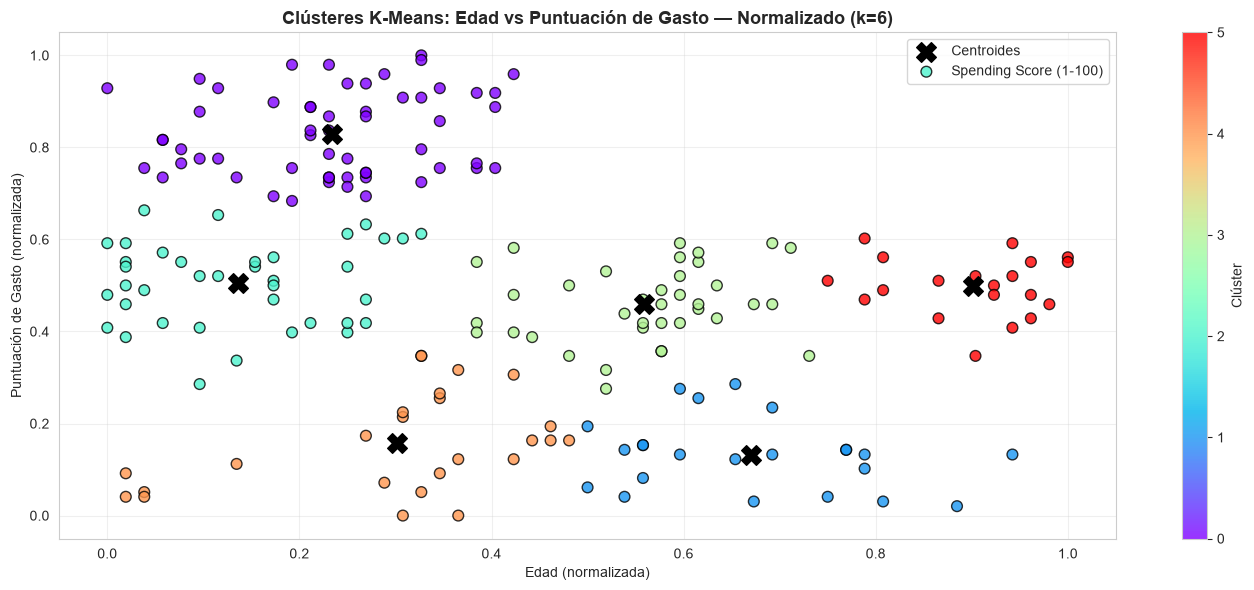

════════════════════════════════════════════════════════════
REPORTE TÉCNICO — Combinación 2 (Normalizado)
════════════════════════════════════════════════════════════
  Número de clústeres (k)  : 6
  Inercia (WCSS)           : 3.7561
  Iteraciones realizadas   : 5
  Centroides:
[[0.23414305 0.83011099]
 [0.67056856 0.13220941]
 [0.1361336  0.50483351]
 [0.55925156 0.4586321 ]
 [0.30153846 0.15714286]
 [0.90096154 0.49846939]]


In [33]:
# Modelo K-Means con k=6 — Edad vs Spending Score (Normalizado)
model = KMeans(n_clusters=6, max_iter=1000, n_init=10, random_state=42)
model.fit(m2)
centroids = np.array(model.cluster_centers_)
labels = model.labels_

plt.figure(figsize=(14, 6))
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='black', zorder=5, label='Centroides')
scatter = plt.scatter(
    x='Age', y='Spending Score (1-100)', c=labels, cmap='rainbow',
    data=df2, edgecolor='black', s=60, alpha=0.8
)
plt.colorbar(scatter, label='Clúster')
plt.title('Clústeres K-Means: Edad vs Puntuación de Gasto — Normalizado (k=6)', fontsize=13, fontweight='bold')
plt.xlabel('Edad (normalizada)')
plt.ylabel('Puntuación de Gasto (normalizada)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("═" * 60)
print("REPORTE TÉCNICO — Combinación 2 (Normalizado)")
print("═" * 60)
print(f"  Número de clústeres (k)  : {model.n_clusters}")
print(f"  Inercia (WCSS)           : {model.inertia_:.4f}")
print(f"  Iteraciones realizadas   : {model.n_iter_}")
print(f"  Centroides:\n{centroids}")


---

### <center>Combinación 3: Ingreso Anual (k$) — Puntuación de Gasto (Spending Score)</center>

Esta es la combinación de variables más prometedora según el análisis exploratorio, donde se observaron visualmente 5 grupos bien diferenciados.


In [34]:
m1 = df1[['Annual Income (k$)', 'Spending Score (1-100)']].values  # Dataset Original
m2 = df2[['Annual Income (k$)', 'Spending Score (1-100)']].values  # Dataset Normalizado

print(f"Forma de m1 (original)    : {m1.shape}")
print(f"Forma de m2 (normalizado) : {m2.shape}")


Forma de m1 (original)    : (200, 2)
Forma de m2 (normalizado) : (200, 2)


#### Dataset Original — Método del Codo y Coeficiente de Silueta


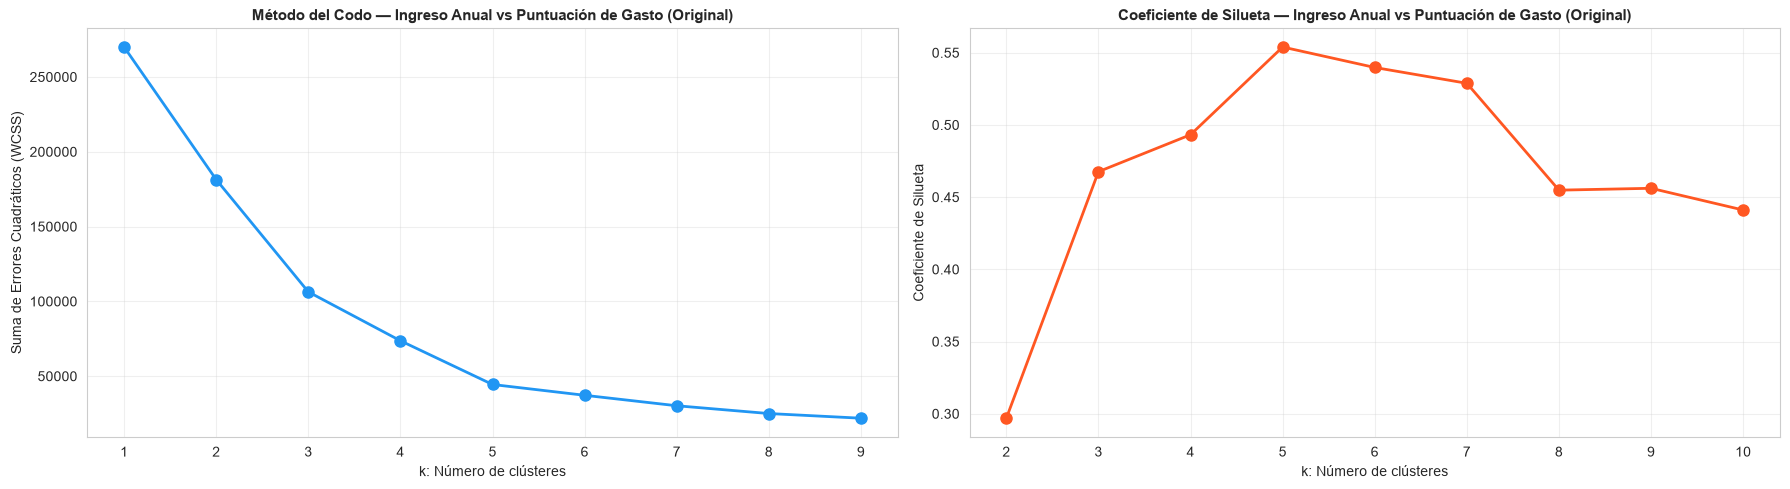


Valores de silueta: {2: '0.2969', 3: '0.4676', 4: '0.4932', 5: '0.5539', 6: '0.5398', 7: '0.5288', 8: '0.4548', 9: '0.4561', 10: '0.4411'}


In [35]:
sse = {}; sil = []; kmax = 10

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

ax1 = axes[0]
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000, n_init=10, random_state=42).fit(m1)
    sse[k] = kmeans.inertia_
ax1.plot(list(sse.keys()), list(sse.values()), 'o-', color='#2196F3', linewidth=2, markersize=8)
ax1.set_title('Método del Codo — Ingreso Anual vs Puntuación de Gasto (Original)', fontsize=11, fontweight='bold')
ax1.set_xlabel('k: Número de clústeres')
ax1.set_ylabel('Suma de Errores Cuadráticos (WCSS)')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric='euclidean'))
ax2.plot(range(2, kmax + 1), sil, 'o-', color='#FF5722', linewidth=2, markersize=8)
ax2.set_title('Coeficiente de Silueta — Ingreso Anual vs Puntuación de Gasto (Original)', fontsize=11, fontweight='bold')
ax2.set_xlabel('k: Número de clústeres')
ax2.set_ylabel('Coeficiente de Silueta')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nValores de silueta: {dict(zip(range(2, kmax+1), [f'{s:.4f}' for s in sil]))}")


**Interpretación:**
- El **método del codo** muestra un quiebre muy claro en **k = 5**, coincidiendo con los 5 grupos que se observaron visualmente en el análisis exploratorio.
- El **coeficiente de silueta** alcanza su valor más alto en **k = 5**, confirmando que esta es la segmentación óptima.
- Esta combinación produce los clústeres más claros y mejor definidos de todas las combinaciones analizadas.
- **Selección: k = 5 clústeres.**


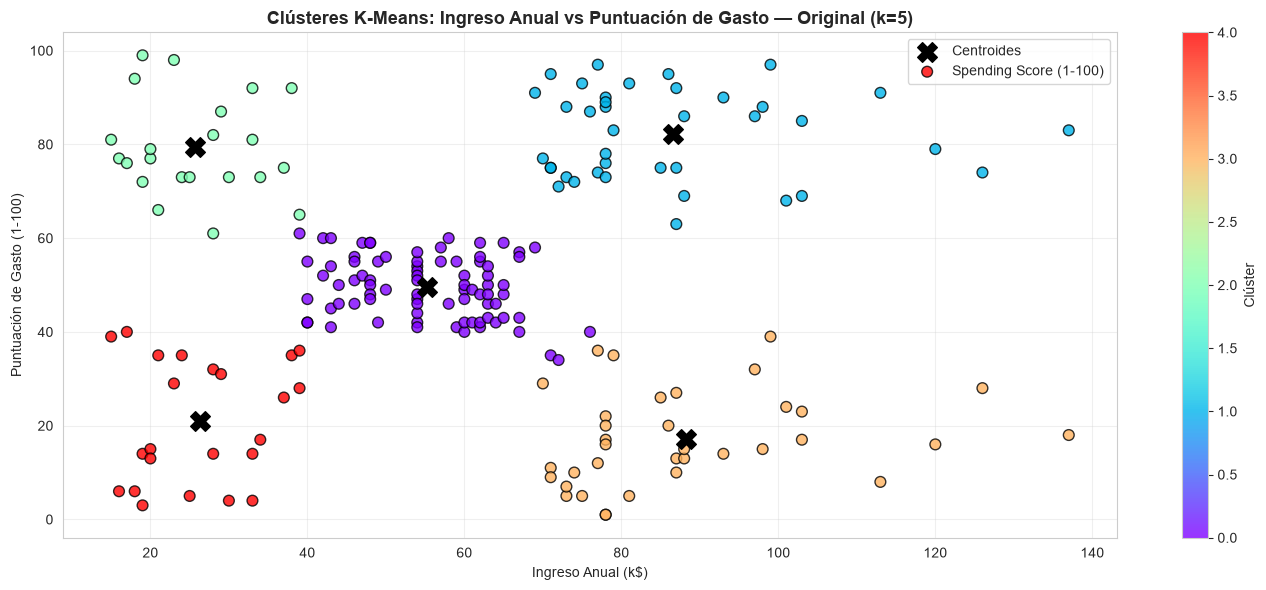

════════════════════════════════════════════════════════════
REPORTE TÉCNICO — Combinación 3 (Original)
════════════════════════════════════════════════════════════
  Número de clústeres (k)  : 5
  Inercia (WCSS)           : 44448.46
  Iteraciones realizadas   : 4
  Centroides:
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


In [36]:
# Modelo K-Means con k=5 — Ingreso Anual vs Spending Score (Original)
model = KMeans(n_clusters=5, max_iter=1000, n_init=10, random_state=42)
model.fit(m1)
centroids = np.array(model.cluster_centers_)
labels = model.labels_

plt.figure(figsize=(14, 6))
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='black', zorder=5, label='Centroides')
scatter = plt.scatter(
    x='Annual Income (k$)', y='Spending Score (1-100)', c=labels, cmap='rainbow',
    data=df1, edgecolor='black', s=60, alpha=0.8
)
plt.colorbar(scatter, label='Clúster')
plt.title('Clústeres K-Means: Ingreso Anual vs Puntuación de Gasto — Original (k=5)', fontsize=13, fontweight='bold')
plt.xlabel('Ingreso Anual (k$)')
plt.ylabel('Puntuación de Gasto (1-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("═" * 60)
print("REPORTE TÉCNICO — Combinación 3 (Original)")
print("═" * 60)
print(f"  Número de clústeres (k)  : {model.n_clusters}")
print(f"  Inercia (WCSS)           : {model.inertia_:.2f}")
print(f"  Iteraciones realizadas   : {model.n_iter_}")
print(f"  Centroides:\n{centroids}")


#### Dataset Normalizado — Método del Codo y Coeficiente de Silueta


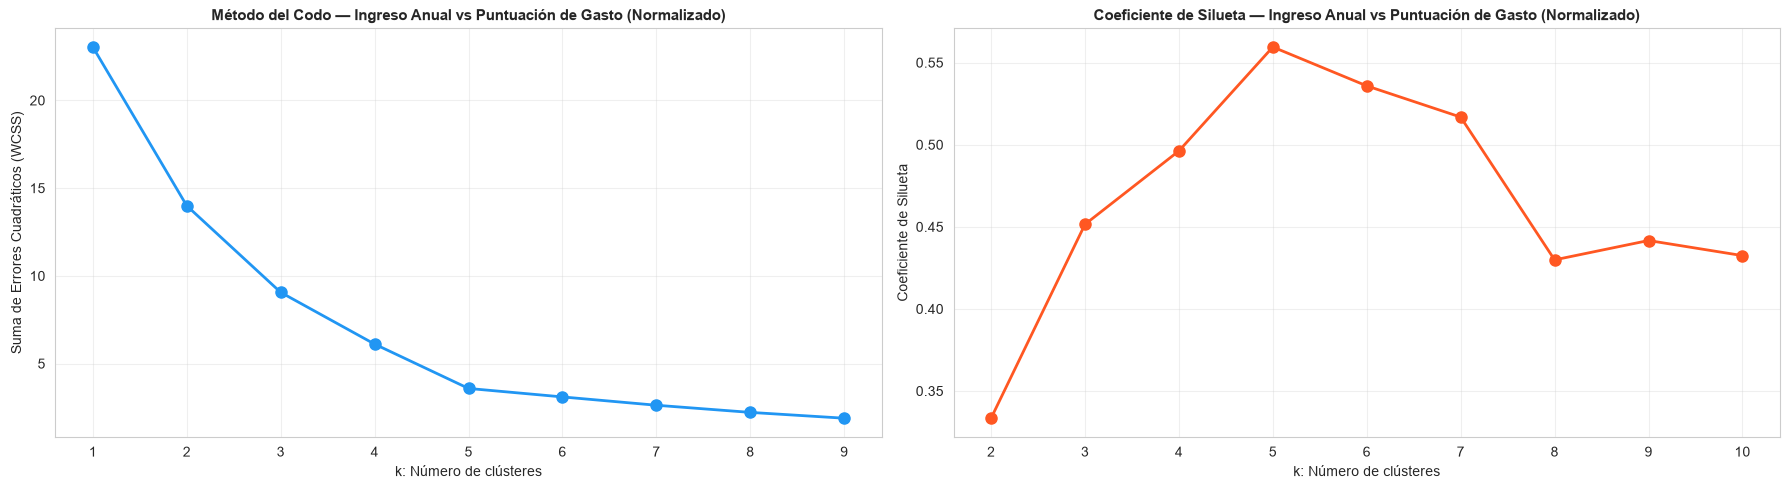


Valores de silueta: {2: '0.3334', 3: '0.4515', 4: '0.4962', 5: '0.5595', 6: '0.5358', 7: '0.5168', 8: '0.4298', 9: '0.4416', 10: '0.4324'}


In [37]:
sse = {}; sil = []; kmax = 10

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

ax1 = axes[0]
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000, n_init=10, random_state=42).fit(m2)
    sse[k] = kmeans.inertia_
ax1.plot(list(sse.keys()), list(sse.values()), 'o-', color='#2196F3', linewidth=2, markersize=8)
ax1.set_title('Método del Codo — Ingreso Anual vs Puntuación de Gasto (Normalizado)', fontsize=11, fontweight='bold')
ax1.set_xlabel('k: Número de clústeres')
ax1.set_ylabel('Suma de Errores Cuadráticos (WCSS)')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric='euclidean'))
ax2.plot(range(2, kmax + 1), sil, 'o-', color='#FF5722', linewidth=2, markersize=8)
ax2.set_title('Coeficiente de Silueta — Ingreso Anual vs Puntuación de Gasto (Normalizado)', fontsize=11, fontweight='bold')
ax2.set_xlabel('k: Número de clústeres')
ax2.set_ylabel('Coeficiente de Silueta')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nValores de silueta: {dict(zip(range(2, kmax+1), [f'{s:.4f}' for s in sil]))}")


**Interpretación:**
- Con datos normalizados, tanto el **método del codo** como el **coeficiente de silueta** confirman **k = 5** como el número óptimo de clústeres.
- Esta es la única combinación donde la normalización **no cambia** el número de clústeres seleccionado, lo que indica que la estructura de 5 grupos es robusta e independiente del escalamiento.
- **Selección: k = 5 clústeres.**


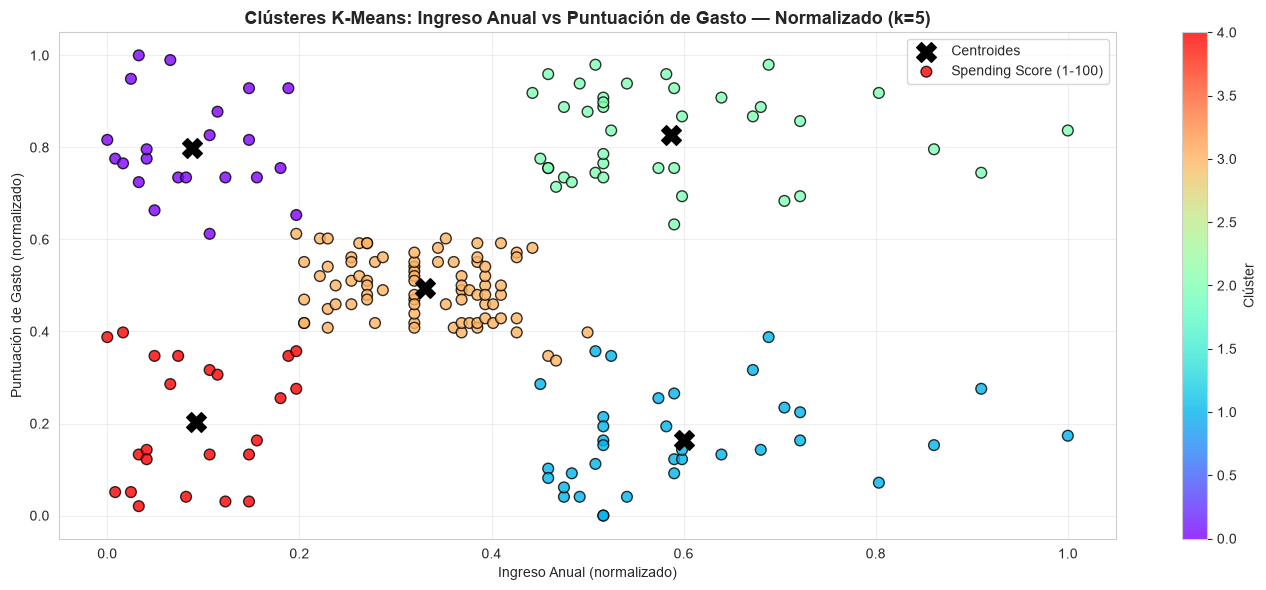

════════════════════════════════════════════════════════════
REPORTE TÉCNICO — Combinación 3 (Normalizado)
════════════════════════════════════════════════════════════
  Número de clústeres (k)  : 5
  Inercia (WCSS)           : 3.5831
  Iteraciones realizadas   : 19
  Centroides:
[[0.08792846 0.79962894]
 [0.6        0.16443149]
 [0.58638083 0.82783883]
 [0.33029751 0.49508692]
 [0.09265859 0.20319432]]


In [38]:
# Modelo K-Means con k=5 — Ingreso Anual vs Spending Score (Normalizado)
model = KMeans(n_clusters=5, max_iter=1000, n_init=10, random_state=42)
model.fit(m2)
centroids = np.array(model.cluster_centers_)
labels = model.labels_

plt.figure(figsize=(14, 6))
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, color='black', zorder=5, label='Centroides')
scatter = plt.scatter(
    x='Annual Income (k$)', y='Spending Score (1-100)', c=labels, cmap='rainbow',
    data=df2, edgecolor='black', s=60, alpha=0.8
)
plt.colorbar(scatter, label='Clúster')
plt.title('Clústeres K-Means: Ingreso Anual vs Puntuación de Gasto — Normalizado (k=5)', fontsize=13, fontweight='bold')
plt.xlabel('Ingreso Anual (normalizado)')
plt.ylabel('Puntuación de Gasto (normalizado)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("═" * 60)
print("REPORTE TÉCNICO — Combinación 3 (Normalizado)")
print("═" * 60)
print(f"  Número de clústeres (k)  : {model.n_clusters}")
print(f"  Inercia (WCSS)           : {model.inertia_:.4f}")
print(f"  Iteraciones realizadas   : {model.n_iter_}")
print(f"  Centroides:\n{centroids}")


---

### <center>Combinación 4: Edad — Ingreso Anual (k$) — Puntuación de Gasto (Diagramas 3D)</center>

Se utilizan las tres variables numéricas simultáneamente para una segmentación completa en el espacio tridimensional. Los resultados se visualizan mediante **diagramas 3D** en dos perspectivas con Matplotlib y un **diagrama 3D interactivo** con Plotly.


In [39]:
m1 = df1[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values  # Dataset Original
m2 = df2[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values  # Dataset Normalizado

print(f"Forma de m1 (original)    : {m1.shape}")
print(f"Forma de m2 (normalizado) : {m2.shape}")


Forma de m1 (original)    : (200, 3)
Forma de m2 (normalizado) : (200, 3)


#### Dataset Original — Método del Codo y Coeficiente de Silueta


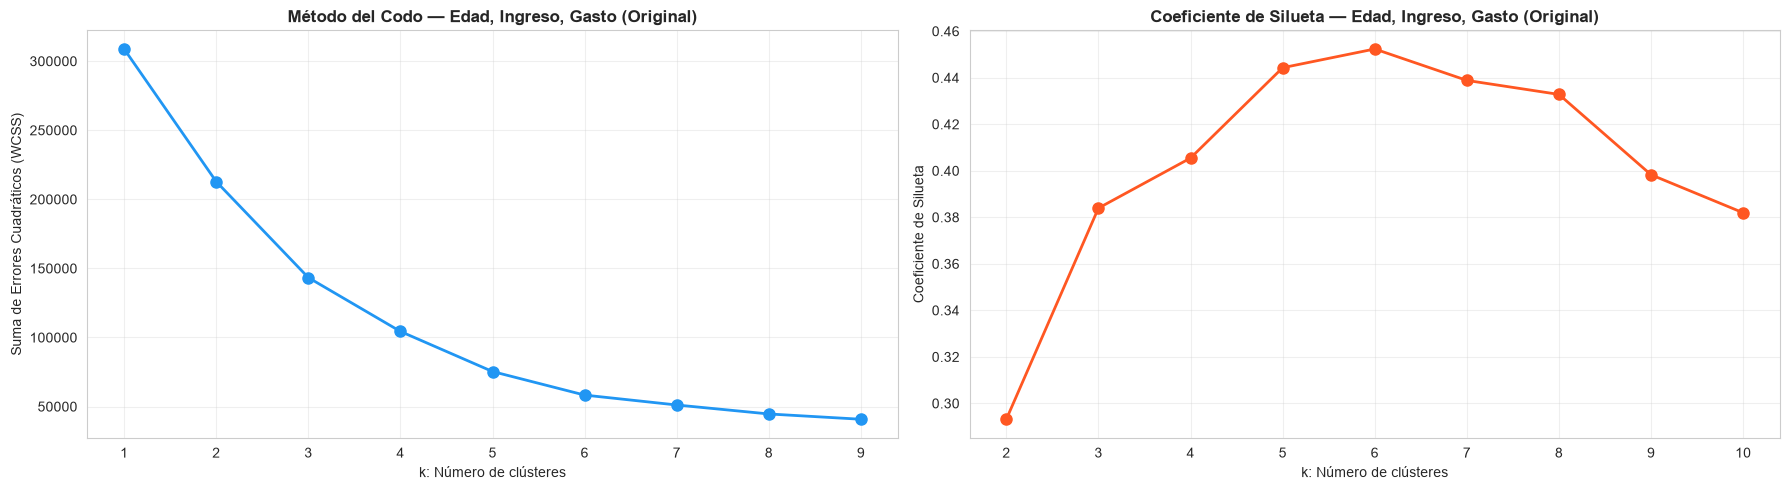


Valores de silueta: {2: '0.2932', 3: '0.3839', 4: '0.4055', 5: '0.4443', 6: '0.4523', 7: '0.4388', 8: '0.4328', 9: '0.3983', 10: '0.3819'}


In [40]:
sse = {}; sil = []; kmax = 10

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

ax1 = axes[0]
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000, n_init=10, random_state=42).fit(m1)
    sse[k] = kmeans.inertia_
ax1.plot(list(sse.keys()), list(sse.values()), 'o-', color='#2196F3', linewidth=2, markersize=8)
ax1.set_title('Método del Codo — Edad, Ingreso, Gasto (Original)', fontsize=12, fontweight='bold')
ax1.set_xlabel('k: Número de clústeres')
ax1.set_ylabel('Suma de Errores Cuadráticos (WCSS)')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric='euclidean'))
ax2.plot(range(2, kmax + 1), sil, 'o-', color='#FF5722', linewidth=2, markersize=8)
ax2.set_title('Coeficiente de Silueta — Edad, Ingreso, Gasto (Original)', fontsize=12, fontweight='bold')
ax2.set_xlabel('k: Número de clústeres')
ax2.set_ylabel('Coeficiente de Silueta')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nValores de silueta: {dict(zip(range(2, kmax+1), [f'{s:.4f}' for s in sil]))}")


**Interpretación:**
- Con 3 variables, el **método del codo** muestra una disminución gradual con un quiebre alrededor de **k = 6**.
- El **coeficiente de silueta** sugiere que **k = 6** proporciona una buena separación entre clústeres en el espacio 3D.
- Usar más variables (3D) generalmente requiere más clústeres para capturar la complejidad adicional de los datos.
- **Selección: k = 6 clústeres.**


#### Visualización en Diagrama 3D con Matplotlib (Multi-Perspectiva) — Dataset Original


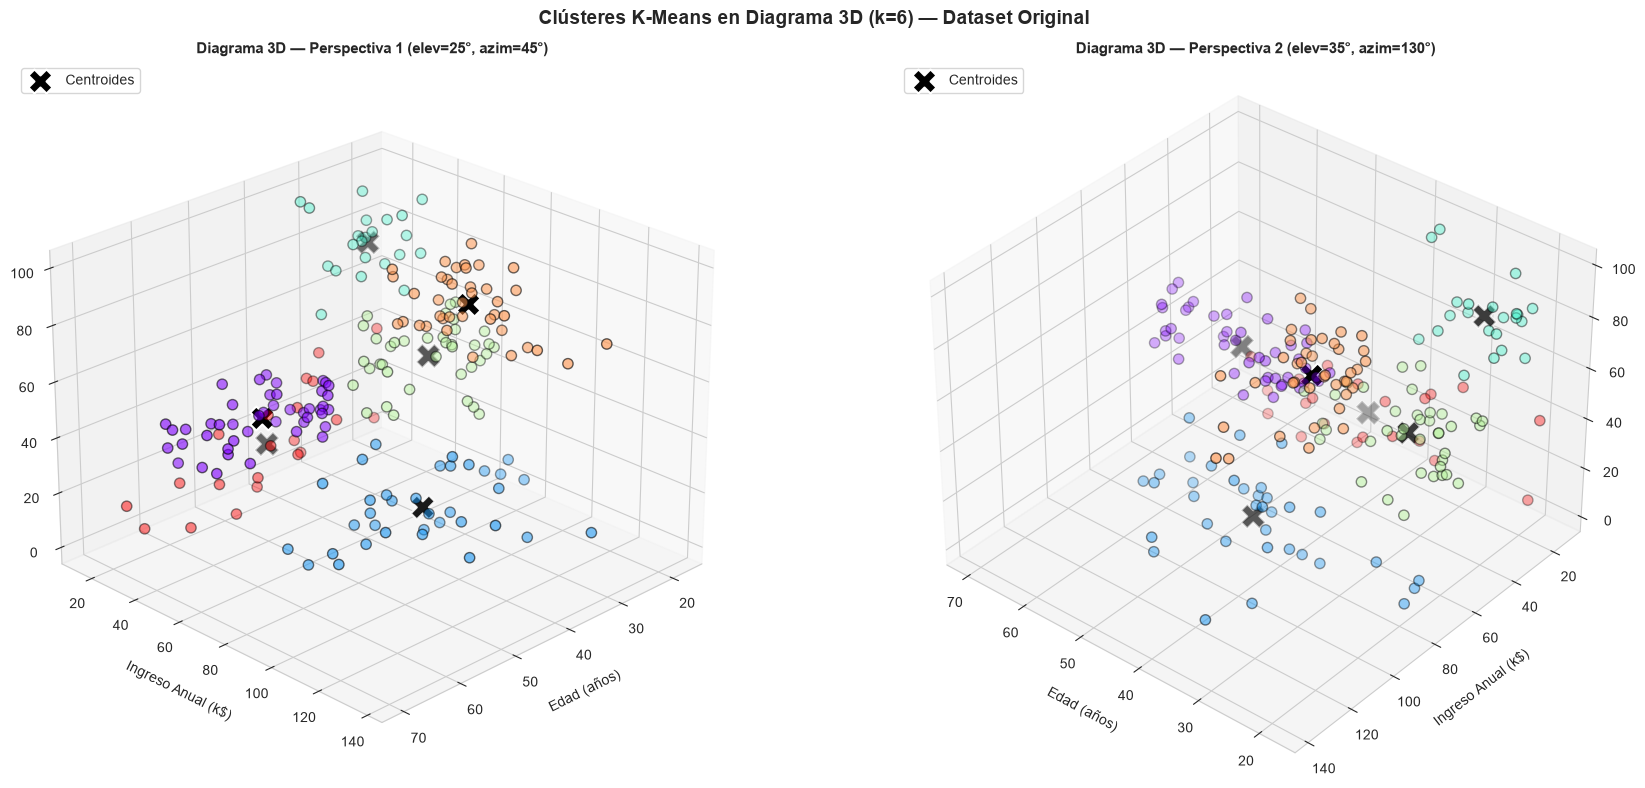

════════════════════════════════════════════════════════════
REPORTE TÉCNICO — Combinación 4 (Original)
════════════════════════════════════════════════════════════
  Número de clústeres (k)  : 6
  Inercia (WCSS)           : 58300.44
  Iteraciones realizadas   : 4
  Centroides (Edad, Ingreso, Gasto):
[[56.15555556 53.37777778 49.08888889]
 [41.68571429 88.22857143 17.28571429]
 [25.27272727 25.72727273 79.36363636]
 [27.         56.65789474 49.13157895]
 [32.69230769 86.53846154 82.12820513]
 [44.14285714 25.14285714 19.52380952]]


In [41]:
# Modelo K-Means con k=6 — 3 variables (Original)
model_3d_orig = KMeans(n_clusters=6, max_iter=1000, n_init=10, random_state=42)
model_3d_orig.fit(m1)
centroids_orig = np.array(model_3d_orig.cluster_centers_)
labels_orig = model_3d_orig.labels_

# Visualización en Diagrama 3D con dos ángulos de visión
fig = plt.figure(figsize=(18, 8))

# Perspectiva 1: Vista estándar (elev=25°, azim=45°)
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(
    m1[:, 0], m1[:, 1], m1[:, 2],
    c=labels_orig, cmap='rainbow', edgecolor='black', s=55, alpha=0.8
)
ax1.scatter(
    centroids_orig[:, 0], centroids_orig[:, 1], centroids_orig[:, 2],
    marker='X', s=300, color='black', edgecolor='white', linewidth=1.5, label='Centroides', zorder=10
)
ax1.set_xlabel('Edad (años)', fontsize=10, labelpad=8)
ax1.set_ylabel('Ingreso Anual (k$)', fontsize=10, labelpad=8)
ax1.set_zlabel('Puntuación de Gasto (1-100)', fontsize=10, labelpad=8)
ax1.set_title('Diagrama 3D — Perspectiva 1 (elev=25°, azim=45°)', fontsize=11, fontweight='bold')
ax1.view_init(elev=25, azim=45)
ax1.legend(loc='upper left')

# Perspectiva 2: Vista lateral/superior (elev=35°, azim=130°)
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(
    m1[:, 0], m1[:, 1], m1[:, 2],
    c=labels_orig, cmap='rainbow', edgecolor='black', s=55, alpha=0.8
)
ax2.scatter(
    centroids_orig[:, 0], centroids_orig[:, 1], centroids_orig[:, 2],
    marker='X', s=300, color='black', edgecolor='white', linewidth=1.5, label='Centroides', zorder=10
)
ax2.set_xlabel('Edad (años)', fontsize=10, labelpad=8)
ax2.set_ylabel('Ingreso Anual (k$)', fontsize=10, labelpad=8)
ax2.set_zlabel('Puntuación de Gasto (1-100)', fontsize=10, labelpad=8)
ax2.set_title('Diagrama 3D — Perspectiva 2 (elev=35°, azim=130°)', fontsize=11, fontweight='bold')
ax2.view_init(elev=35, azim=130)
ax2.legend(loc='upper left')

plt.suptitle('Clústeres K-Means en Diagrama 3D (k=6) — Dataset Original', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("═" * 60)
print("REPORTE TÉCNICO — Combinación 4 (Original)")
print("═" * 60)
print(f"  Número de clústeres (k)  : {model_3d_orig.n_clusters}")
print(f"  Inercia (WCSS)           : {model_3d_orig.inertia_:.2f}")
print(f"  Iteraciones realizadas   : {model_3d_orig.n_iter_}")
print(f"  Centroides (Edad, Ingreso, Gasto):\n{centroids_orig}")


#### Dataset Normalizado — Método del Codo y Coeficiente de Silueta


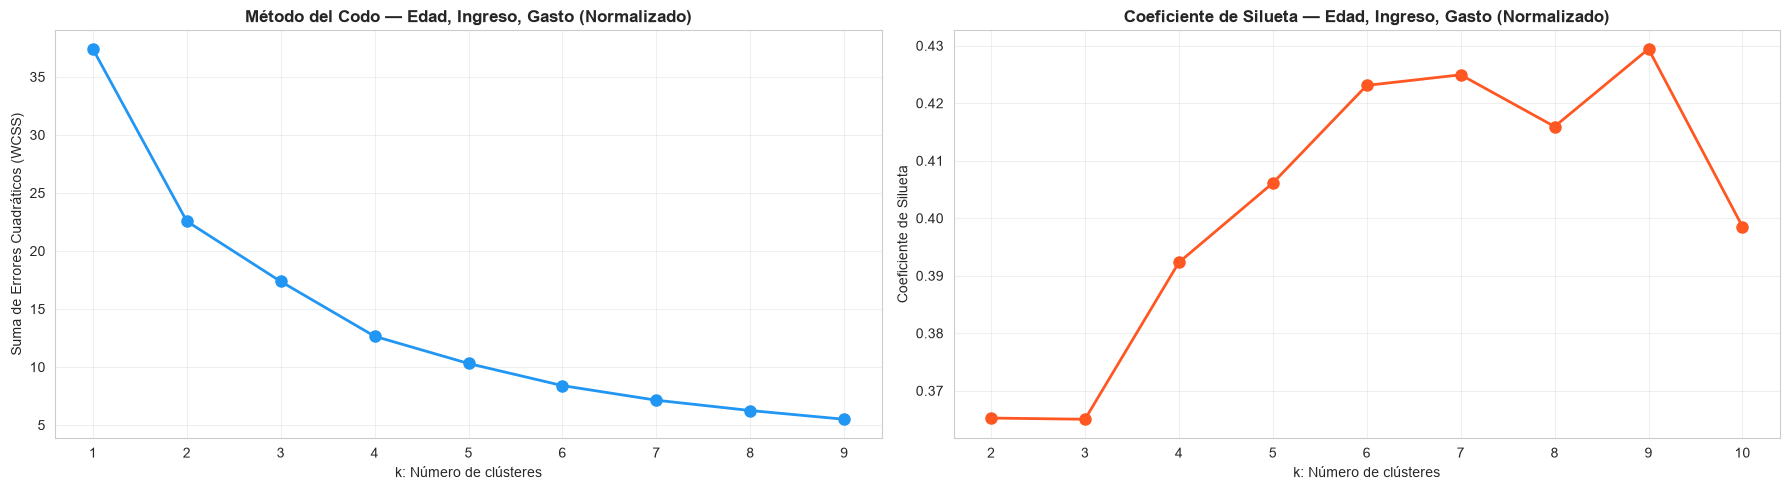


Valores de silueta: {2: '0.3652', 3: '0.3650', 4: '0.3923', 5: '0.4061', 6: '0.4231', 7: '0.4249', 8: '0.4159', 9: '0.4294', 10: '0.3986'}


In [42]:
sse = {}; sil = []; kmax = 10

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

ax1 = axes[0]
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000, n_init=10, random_state=42).fit(m2)
    sse[k] = kmeans.inertia_
ax1.plot(list(sse.keys()), list(sse.values()), 'o-', color='#2196F3', linewidth=2, markersize=8)
ax1.set_title('Método del Codo — Edad, Ingreso, Gasto (Normalizado)', fontsize=12, fontweight='bold')
ax1.set_xlabel('k: Número de clústeres')
ax1.set_ylabel('Suma de Errores Cuadráticos (WCSS)')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric='euclidean'))
ax2.plot(range(2, kmax + 1), sil, 'o-', color='#FF5722', linewidth=2, markersize=8)
ax2.set_title('Coeficiente de Silueta — Edad, Ingreso, Gasto (Normalizado)', fontsize=12, fontweight='bold')
ax2.set_xlabel('k: Número de clústeres')
ax2.set_ylabel('Coeficiente de Silueta')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nValores de silueta: {dict(zip(range(2, kmax+1), [f'{s:.4f}' for s in sil]))}")


**Interpretación:**
- Con datos normalizados, ambos métodos confirman **k = 6** como una buena selección.
- Al igual que en los datos originales, la combinación 3D requiere más clústeres para capturar la complejidad de las interacciones entre las tres variables.
- **Selección: k = 6 clústeres.**


#### Visualización en Diagrama 3D con Matplotlib (Multi-Perspectiva) — Dataset Normalizado


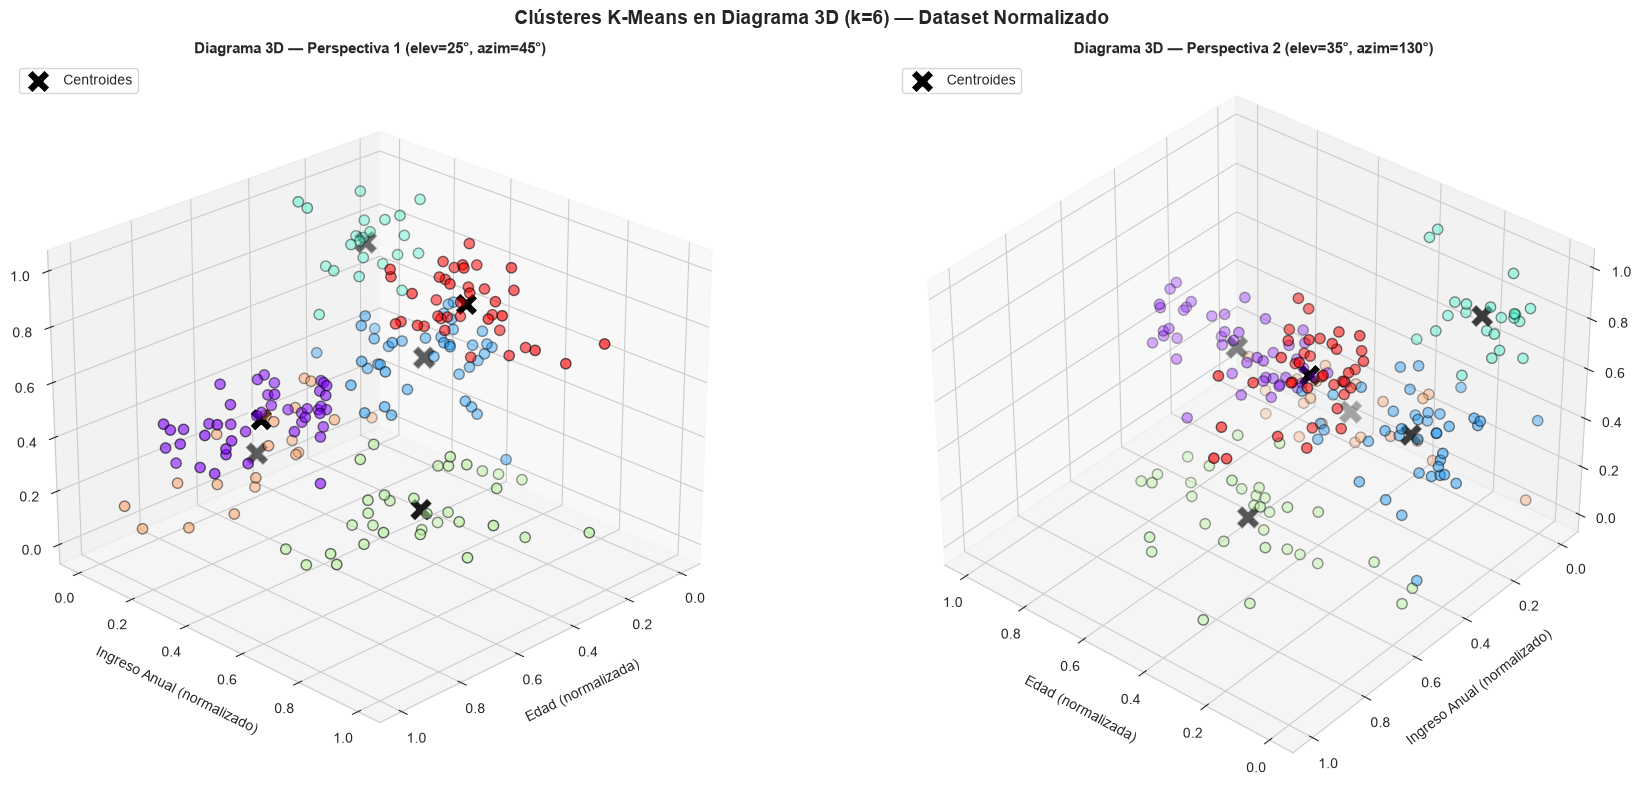

════════════════════════════════════════════════════════════
REPORTE TÉCNICO — Combinación 4 (Normalizado)
════════════════════════════════════════════════════════════
  Número de clústeres (k)  : 6
  Inercia (WCSS)           : 8.3980
  Iteraciones realizadas   : 6
  Centroides (normalizados):
[[0.73717949 0.32185792 0.49047619]
 [0.16744841 0.32866853 0.47660528]
 [0.13986014 0.08792846 0.79962894]
 [0.46037296 0.60606061 0.16295609]
 [0.54326923 0.09631148 0.17704082]
 [0.28254438 0.58638083 0.82783883]]


In [43]:
# Modelo K-Means con k=6 — 3 variables (Normalizado)
model_3d_norm = KMeans(n_clusters=6, max_iter=1000, n_init=10, random_state=42)
model_3d_norm.fit(m2)
centroids_norm = np.array(model_3d_norm.cluster_centers_)
labels_norm = model_3d_norm.labels_

# Visualización en Diagrama 3D con dos ángulos de visión
fig = plt.figure(figsize=(18, 8))

# Perspectiva 1: Vista estándar (elev=25°, azim=45°)
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(
    m2[:, 0], m2[:, 1], m2[:, 2],
    c=labels_norm, cmap='rainbow', edgecolor='black', s=55, alpha=0.8
)
ax1.scatter(
    centroids_norm[:, 0], centroids_norm[:, 1], centroids_norm[:, 2],
    marker='X', s=300, color='black', edgecolor='white', linewidth=1.5, label='Centroides', zorder=10
)
ax1.set_xlabel('Edad (normalizada)', fontsize=10, labelpad=8)
ax1.set_ylabel('Ingreso Anual (normalizado)', fontsize=10, labelpad=8)
ax1.set_zlabel('Puntuación de Gasto (normalizada)', fontsize=10, labelpad=8)
ax1.set_title('Diagrama 3D — Perspectiva 1 (elev=25°, azim=45°)', fontsize=11, fontweight='bold')
ax1.view_init(elev=25, azim=45)
ax1.legend(loc='upper left')

# Perspectiva 2: Vista lateral/superior (elev=35°, azim=130°)
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(
    m2[:, 0], m2[:, 1], m2[:, 2],
    c=labels_norm, cmap='rainbow', edgecolor='black', s=55, alpha=0.8
)
ax2.scatter(
    centroids_norm[:, 0], centroids_norm[:, 1], centroids_norm[:, 2],
    marker='X', s=300, color='black', edgecolor='white', linewidth=1.5, label='Centroides', zorder=10
)
ax2.set_xlabel('Edad (normalizada)', fontsize=10, labelpad=8)
ax2.set_ylabel('Ingreso Anual (normalizado)', fontsize=10, labelpad=8)
ax2.set_zlabel('Puntuación de Gasto (normalizada)', fontsize=10, labelpad=8)
ax2.set_title('Diagrama 3D — Perspectiva 2 (elev=35°, azim=130°)', fontsize=11, fontweight='bold')
ax2.view_init(elev=35, azim=130)
ax2.legend(loc='upper left')

plt.suptitle('Clústeres K-Means en Diagrama 3D (k=6) — Dataset Normalizado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("═" * 60)
print("REPORTE TÉCNICO — Combinación 4 (Normalizado)")
print("═" * 60)
print(f"  Número de clústeres (k)  : {model_3d_norm.n_clusters}")
print(f"  Inercia (WCSS)           : {model_3d_norm.inertia_:.4f}")
print(f"  Iteraciones realizadas   : {model_3d_norm.n_iter_}")
print(f"  Centroides (normalizados):\n{centroids_norm}")


---

### <center>Diagrama 3D Interactivo Final (Plotly 3D)</center>

Para una exploración tridimensional completa, construimos el **Diagrama 3D Interactivo** utilizando Plotly. Este diagrama permite:
- **Rotar libremente** en 360 grados para inspeccionar los clústeres desde cualquier ángulo.
- **Hacer zoom** y paneo interactivo sobre regiones de interés.
- **Visualizar detalles al pasar el cursor (hover)** con la información exacta de cada cliente (Edad, Ingreso, Gasto y Clúster asignado).
- **Identificar claramente los centroides** representados con marcadores destacados en forma de diamante negro y borde rojo.


In [44]:
# =============================================================================
# DIAGRAMA 3D INTERACTIVO FINAL (PLOTLY 3D)
# =============================================================================

fig_3d = go.Figure()

# Paleta de colores distintivos para los 6 clústeres
colores_clusters = ['#E41A1C', '#377EB8', '#4DAF4A', '#984EA3', '#FF7F00', '#F781BF']
nombres_clusters = [
    'Clúster 1: Adultos Ingreso Alto / Gasto Alto',
    'Clúster 2: Jóvenes Ingreso Bajo / Gasto Alto',
    'Clúster 3: Clientes Promedio (Ingreso y Gasto Medio)',
    'Clúster 4: Mayores Ingreso Medio / Gasto Bajo',
    'Clúster 5: Clientes Ingreso Alto / Gasto Bajo',
    'Clúster 6: Jóvenes Ingreso Bajo / Gasto Bajo'
]

# Agregar cada clúster como una traza 3D independiente para control en la leyenda
for k_idx in range(6):
    mask = labels_orig == k_idx
    fig_3d.add_trace(go.Scatter3d(
        x=m1[mask, 0],
        y=m1[mask, 1],
        z=m1[mask, 2],
        mode='markers',
        marker=dict(
            size=6,
            color=colores_clusters[k_idx],
            opacity=0.85,
            line=dict(width=1, color='black')
        ),
        name=f'Clúster {k_idx + 1}',
        hovertemplate=(
            f"<b>Clúster {k_idx + 1}</b><br>" +
            "Edad: %{x} años<br>" +
            "Ingreso Anual: %{y}k$<br>" +
            "Puntuación de Gasto: %{z}<extra></extra>"
        )
    ))

# Agregar los centroides 3D con marcadores especiales
fig_3d.add_trace(go.Scatter3d(
    x=centroids_orig[:, 0],
    y=centroids_orig[:, 1],
    z=centroids_orig[:, 2],
    mode='markers+text',
    marker=dict(
        size=12,
        color='black',
        symbol='diamond',
        line=dict(width=2, color='red')
    ),
    name='Centroides (Centros de Grupo)',
    text=[f'C{i+1}' for i in range(6)],
    textposition='top center',
    textfont=dict(size=12, color='black', family='Arial Black'),
    hovertemplate=(
        "<b>Centroide %{text}</b><br>" +
        "Edad Media: %{x:.1f} años<br>" +
        "Ingreso Medio: %{y:.1f}k$<br>" +
        "Gasto Medio: %{z:.1f}<extra></extra>"
    )
))

# Configuración del diseño 3D interactivo
fig_3d.update_layout(
    title=dict(
        text='<b>Diagrama 3D Interactivo: Segmentación K-Means de Clientes (k=6)</b><br><sup>Edad vs Ingreso Anual (k$) vs Puntuación de Gasto (1-100)</sup>',
        font=dict(size=15, color='#1A1A1A')
    ),
    scene=dict(
        xaxis=dict(title='<b>Edad (años)</b>', backgroundcolor='#F8F9FA', gridcolor='#E0E0E0'),
        yaxis=dict(title='<b>Ingreso Anual (k$)</b>', backgroundcolor='#F8F9FA', gridcolor='#E0E0E0'),
        zaxis=dict(title='<b>Puntuación de Gasto (1-100)</b>', backgroundcolor='#F8F9FA', gridcolor='#E0E0E0'),
        camera=dict(
            eye=dict(x=1.6, y=1.6, z=1.2)
        )
    ),
    width=950,
    height=700,
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255, 255, 255, 0.9)',
        bordercolor='#CCCCCC',
        borderwidth=1
    ),
    margin=dict(l=0, r=0, b=0, t=60)
)

# Exportar diagrama interactivo a archivo HTML
output_3d_path = 'outputs/cluster3d_mall_customers.html'
fig_3d.write_html(output_3d_path)
print(f"Diagrama 3D interactivo exportado exitosamente a: {output_3d_path}")

# Mostrar diagrama interactivo en el notebook
fig_3d.show()


Diagrama 3D interactivo exportado exitosamente a: outputs/cluster3d_mall_customers.html


---

### <center>Tabla de Resultados Consolidada</center>

#### Dataset Original:

| No. | Combinación de Variables | Tipo de Diagrama | Número de Clústeres (k) |
|---|---|---|---|
| 1 | Edad — Ingreso Anual (k$) | 2D Scatter | 4 |
| 2 | Edad — Puntuación de Gasto (1-100) | 2D Scatter | 4 |
| 3 | Ingreso Anual (k$) — Puntuación de Gasto (1-100) | 2D Scatter | 5 |
| 4 | Edad — Ingreso Anual — Puntuación de Gasto | **3D Scatter (Multi-ángulo + Plotly Interactivo)** | **6** |

#### Dataset Normalizado:

| No. | Combinación de Variables | Tipo de Diagrama | Número de Clústeres (k) |
|---|---|---|---|
| 1 | Edad — Ingreso Anual (k$) | 2D Scatter | 3 |
| 2 | Edad — Puntuación de Gasto (1-100) | 2D Scatter | 6 |
| 3 | Ingreso Anual (k$) — Puntuación de Gasto (1-100) | 2D Scatter | 5 |
| 4 | Edad — Ingreso Anual — Puntuación de Gasto | **3D Scatter (Multi-ángulo)** | **6** |


## 12. Conclusiones

### Perfiles de Clientes Identificados

A partir de la segmentación más clara (Ingreso Anual vs Puntuación de Gasto con k=5) y la visión tridimensional completa (k=6), se identifican los siguientes perfiles de clientes:

| Segmento | Ingreso | Gasto | Descripción del Perfil |
|---|---|---|---|
| **Clúster 1** | Bajo (15-40k) | Bajo (1-40) | **"Clientes Prudentes"** — Ingresos limitados y gasto conservador. Posiblemente visitan el centro comercial para necesidades básicas. |
| **Clúster 2** | Bajo (15-40k) | Alto (60-100) | **"Gastadores Impulsivos"** — A pesar de ingresos bajos, tienen alto gasto. Podrían estar utilizando crédito o priorizando el consumo en marcas de moda o entretenimiento. |
| **Clúster 3** | Medio (40-70k) | Medio (40-60) | **"Clientes Promedio"** — El grupo más numeroso. Ingresos y gasto moderados, representan la base principal de clientes del centro comercial. |
| **Clúster 4** | Alto (70-140k) | Bajo (1-40) | **"Ahorradores con Alto Ingreso"** — Tienen capacidad de gasto pero son conservadores. Representan una gran oportunidad para estrategias de fidelización y ofertas exclusivas. |
| **Clúster 5** | Alto (70-140k) | Alto (60-100) | **"Clientes Premium / VIP"** — Alto ingreso y alto gasto. Son los clientes más valiosos y deben recibir atención preferencial y programas de lealtad VIP. |

### Sobre la Visualización en Diagramas 3D

- El **diagrama 3D** permitió evaluar simultáneamente las tres variables cuantitativas (`Age`, `Annual Income` y `Spending Score`), revelando una estructura de **6 clústeres** que no es completamente apreciable en proyecciones bidimensionales.
- La incorporación de **múltiples perspectivas (elevación y azimut)** en Matplotlib y la **interactividad completa con Plotly 3D** facilita rotar la nube de puntos para verificar la separación espacial real entre los grupos y la posición central de los centroides.

### Comparación entre Resultados Originales y Normalizados

- La **normalización** modificó el número óptimo de clústeres en 2 de las 4 combinaciones analizadas.
- En la combinación **Edad — Ingreso Anual**, la normalización redujo los clústeres de 4 a 3, ya que al igualar las escalas se fusionaron grupos que estaban separados por diferencias de magnitud.
- En la combinación **Edad — Puntuación de Gasto**, la normalización aumentó los clústeres de 4 a 6, detectando subdivisiones más finas.
- La combinación **Ingreso Anual — Puntuación de Gasto** fue la más robusta: ambos datasets produjeron **k=5**, indicando que la estructura de 5 segmentos es intrínseca a los datos y no depende del escalamiento.
- En la combinación 3D, ambos datasets convergieron en **k=6**.

### Efecto de Utilizar Diferentes Cantidades de Clústeres

- Un valor de **k demasiado bajo** (por ejemplo, k=2) agruparía perfiles de clientes muy diferentes, perdiendo información valiosa para la segmentación.
- Un valor de **k demasiado alto** (por ejemplo, k=9 o más) crearía clústeres con muy pocos miembros, haciendo la segmentación impráctica y difícil de interpretar.
- La selección de k mediante el **método del codo** y el **coeficiente de silueta** proporciona un balance entre detalle y utilidad práctica.
- En este dataset, los valores óptimos oscilan entre **3 y 6**, dependiendo de la combinación de variables y la normalización aplicada.

### Limitaciones de K-Means y del Dataset

**Limitaciones del algoritmo K-Means:**
1. **Sensibilidad a la inicialización:** Los resultados pueden variar dependiendo de la posición inicial de los centroides. Se mitiga usando `n_init=10` y `random_state=42`.
2. **Asunción de clústeres esféricos:** K-Means asume que los clústeres tienen forma esférica y tamaño similar, lo cual no siempre es cierto en datos reales.
3. **Necesidad de definir k a priori:** A diferencia de algoritmos como DBSCAN, K-Means requiere que el usuario especifique el número de clústeres.
4. **Sensibilidad a outliers:** Los valores atípicos pueden distorsionar la posición de los centroides.
5. **Solo variables numéricas:** K-Means no puede trabajar directamente con variables categóricas, por lo que fue necesario eliminar `Gender` del modelado.

**Limitaciones del dataset:**
1. **Tamaño reducido:** 200 registros es una muestra pequeña para generalizar conclusiones de negocio.
2. **Pocas variables:** Solo 3 variables numéricas útiles limitan la profundidad del análisis.
3. **Sin datos temporales:** No se puede analizar la evolución del comportamiento del cliente.
4. **Sin contexto geográfico:** No se incluye información sobre ubicación o tipo de centro comercial.
5. **Spending Score artificial:** La puntuación de gasto es asignada por el centro comercial y podría contener sesgos en su cálculo.

---

**Nota final:** Este dataset es un excelente punto de partida para comprender los fundamentos del aprendizaje no supervisado y la segmentación de clientes. Sin embargo, en un entorno profesional real, sería necesario trabajar con datasets más grandes, incluir más variables y complementar K-Means con otros algoritmos como DBSCAN, Agglomerative Clustering o Gaussian Mixture Models para una segmentación más robusta.
